In [2]:
import astropy.io.fits as fits
import numpy as np
import matplotlib.pyplot as plt
import glob

from astropy.time import Time
from astropy.coordinates import EarthLocation, SkyCoord
import astropy.units as u
from astroquery.simbad import Simbad

import pandas as pd
import os

# Specify basepath and target

Change the basepath to the RLMT folder and specify your target of choice to derive a wavelength calibration

In [63]:
# basepath = os.path.expanduser('~/gdrive/Shared drives/MACRO-Be/resources/calibrated_data/')
basepath = os.path.expanduser('~/Desktop/Code/reduced_data/')
# target = 'V742_Cas'
# target = 'HD_44637'
# target = 'HIP_50335'
# target = 'HIP_67301'
# target = 'HIP_50372'
# target = 'HIP_63125'
# target = 'RY_Sct'

# target = 'HIP_36850'
target = 'rigel'

#Define the patterns for the directories
patterns = [
    #f"{basepath}/2024-12-2*/*lrg*.fts",  # Matches directories starting with 2024-12-2*
    f"{basepath}/2024-12-2*/*{target}*hrg*.fz",  # Matches directories starting with 2024-12-2*
    #f"{basepath}/2025*/*lrg*.fts",       # Matches directories starting with 2025*
    f"{basepath}/2025*/*{target}*hrg*.fz",       # Matches directories starting with 2025*
]

#Use glob to find all matching FITS files
img_files = []
for pattern in patterns:
    img_files.extend(glob.glob(pattern))

#Print the result
print(f"Found {len(img_files)} FITS files:")
print(f"   ---> {len(img_files)} found")

Found 10 FITS files:
   ---> 10 found


In [64]:
# Use this block to select image with CENTERED = True:
centered_list = []
exptime_list = []
for i in range(len(img_files)):
    with fits.open(img_files[i]) as hdul:
        header = hdul[1].header
        centered = header["CENTERED"]
        if centered == True:
            centered_list.append(img_files[i])
            exptime_list.append(header["EXPTIME"])
        else:
            pass

# Sort by exptime in descending order
sorted_pairs = sorted(zip(exptime_list, centered_list), reverse=True)
sorted_exptime_list, sorted_centered_list = zip(*sorted_pairs)

# Optional: convert back to lists
sorted_exptime_list = list(sorted_exptime_list)
sorted_centered_list = list(sorted_centered_list)
    
# Find the maximum exposure time
max_exptime = sorted_exptime_list[0]

# Filter the list to only include images with the maximum exposure time
max_exptime_images = [img for exp, img in zip(sorted_exptime_list, sorted_centered_list) if exp == max_exptime]

# Print the images with the maximum exposure time
print("Centered images with the maximum exposure time:")
for img in max_exptime_images:
    print(f"   ---> {str.split(img,'/')[-1]}: {max_exptime} s")



img_index = 0 # Select desired image index, here I have specified the image with an integration time of 61 s
print('')
print(str.split(max_exptime_images[img_index],'/')[-1]) 

Centered images with the maximum exposure time:
   ---> jos_rigel_hrg_8s_2025-11-24T08-16-14.fts.fz: 8.0 s

jos_rigel_hrg_8s_2025-11-24T08-16-14.fts.fz


# Doppler Shift Wavelength Correction

You do not have to change anything in this section, just run all of the blocks

In [65]:
# Query Simbad for the recessional velocity of the target

# Reset to default fields
Simbad.reset_votable_fields()

# List available votable fields
print("Available votable fields:")
print(Simbad.list_votable_fields())

Simbad.add_votable_fields('rvz_radvel')

star_name = target
result_table = Simbad.query_object(star_name)

if result_table is None:
    print(f"No results found for {star_name}.")
else:
    print("Returned columns:", result_table.colnames)
    
    if 'rvz_radvel' in result_table.colnames:
        rv = result_table['rvz_radvel'][0]
        if rv is None:
            print('')
            print(f"No radial (recessional) velocity available for {star_name}.")
            print('')
        else:
            print('')
            print(f"The radial (recessional) velocity of {star_name} is {rv} km/s.")
            print('')
    else:
        print("Radial velocity column not found in the result. Available columns are:")
        print(result_table.colnames)

Available votable fields:
    name    ...     type   
----------- ... -----------
mesDiameter ...       table
      mesPM ...       table
     mesISO ...       table
     mesSpT ...       table
  allfluxes ...       table
      ident ...       table
       flux ...       table
   mesOtype ...       table
     mesPLX ...       table
   otypedef ...       table
        ... ...         ...
          K ... filter name
          u ... filter name
          g ... filter name
          r ... filter name
          i ... filter name
          z ... filter name
          G ... filter name
      F150W ... filter name
      F200W ... filter name
      F444W ... filter name
Length = 116 rows
Returned columns: ['main_id', 'ra', 'dec', 'coo_err_maj', 'coo_err_min', 'coo_err_angle', 'coo_wavelength', 'coo_bibcode', 'rvz_radvel', 'matched_id']

The radial (recessional) velocity of rigel is 17.8 km/s.



In [66]:
# Calculate earth radial velocity correction with astropy for rigel based on DATE-OBS in header

# Get the DATE-OBS from the header
with fits.open(max_exptime_images[img_index]) as hdul:
    header = hdul[1].header
# header = fits.getheader(max_exptime_images[img_index])
date_obs = header['DATE-OBS']
print(date_obs)

target_name = target.replace('_',' ')
print(f'Target: {target_name}')

# Should really pull the target from the header...
target_sc = SkyCoord.from_name(target_name)
print(target_sc)

# Get the observatory location
obs_loc = EarthLocation.of_site('Winer')
print(obs_loc)

# Convert date_obs to astropy time
t = Time(date_obs, format='isot', scale='utc', location=obs_loc)
print(t)

radial_vel_correction = target_sc.radial_velocity_correction(obstime=t).to('km/s')
print("Earth motion velocity: ", radial_vel_correction)

2025-11-24T08:24:45.97
Target: rigel
<SkyCoord (ICRS): (ra, dec) in deg
    (78.63446707, -8.20163837)>
(-1912384.9030059641, -5087336.881556098, 3329722.618648529) m
2025-11-24T08:24:45.970
Earth motion velocity:  6.361281139787957 km / s


In [67]:
# Caclulate a wavelength correction factor based on target recessional velocity and Earth motion

rv_tot = (rv*u.km/u.s + radial_vel_correction)
print(f'Total radial velocity motion: {rv_tot}')

c = 299792.458 * u.km/u.s  # Speed of light in km/s
z = (rv*u.km/u.s + radial_vel_correction)/c
wavelength_correction = 1 + z
print("Wavelength Correction Factor:", wavelength_correction)
if wavelength_correction < 1:
    print('Light is blue shifted')
if wavelength_correction > 1:
    print('Light is red shifted')

Total radial velocity motion: 24.16128113978796 km / s
Wavelength Correction Factor: 1.0000805933588222
Light is red shifted


# Image Processing --> Normalized Spectrum

You do not have to change anything in this section, just run all of the blocks

In [68]:
def get_img_data(img_file):
    img_data = fits.getdata(img_file)
    return img_data

def plot_img(img_data, aspect_ratio=1):
    plt.imshow(img_data, cmap='gray', origin='lower')
    plt.gca().set_aspect(aspect_ratio)
    plt.colorbar()
    plt.show()

def extract_strip(img_data, height, center_row):
    strip_data = img_data[center_row - height//2:center_row + height//2, :]
    return strip_data

In [69]:
from scipy import stats

def fit_line(data, xlow = None, xhigh = None, ylow = None, yhigh = None, min_intensity = None, recursion = 0):

    if xlow is None:
        xlow = 0
    if xhigh is None:
        xhigh = data.shape[1]
    if ylow is None:
        ylow = 0
    if yhigh is None:
        yhigh = data.shape[0]
    if min_intensity is None:
        min_intensity = 3*np.mean(data)

    if recursion > 30:
        print('')
        print('fit_line failed: Unable to fit spectral trace')
        print('')
        return

    if data.shape[0] < data.shape[1]:
        plot_data = data
        data = np.transpose(data)
    else:
        plot_data = np.transpose(data)

    x_fit = []
    y_fit = []
    for i in range(data.shape[0]):
        max_x_coord = i
        max_y_coord = np.where(data[i] == np.max(data[i]))[0][0]
        if max_x_coord < xlow or max_x_coord > xhigh:
            continue
        if max_y_coord < ylow or max_y_coord > yhigh:
            continue
        else:
            x_fit.append(max_x_coord)
            y_fit.append(max_y_coord)

    a = 0
    while a < len(y_fit):
        if data[x_fit[a]][y_fit[a]] < min_intensity:
            del x_fit[a]
            del y_fit[a]
        else:
            a+=1
            continue

    if len(y_fit) < (xhigh-xlow)/4:
        # print("Re-fit, not enough data points")
        # print('Failed to make fit, trying a new min_intensity parameter...')
        new_min_intensity = min_intensity - 0.25*np.mean(data)
        return fit_line(data,xlow = xlow,xhigh = xhigh,ylow = ylow,yhigh = yhigh,min_intensity = new_min_intensity, recursion = recursion)

    x_fit = np.array(x_fit)
    y_fit = np.array(y_fit)

    slope, intercept, r_value, p_value, std_err = stats.linregress(x_fit, y_fit)
    y_pred = intercept + slope * x_fit
    residuals = y_fit - y_pred

    threshold = .15 * np.std(residuals)
    outliers = np.abs(residuals) > threshold
    x_fit = x_fit[~outliers]
    y_fit = y_fit[~outliers]

    joshfit = np.polyfit(x_fit,y_fit,1)
    m, b = joshfit[0], joshfit[1]
    x=np.linspace(0,data.shape[1]-1,data.shape[1])
    fitline = m*x + b

    poly = np.poly1d(joshfit)
    yfit = poly(x_fit)
    residuals = y_fit - yfit
    ss_res = np.sum(residuals**2)
    ss_tot = np.sum((yfit - np.mean(yfit))**2)
    r_squared = 1 - (ss_res / ss_tot)

    if np.abs(r_squared) > 1.05 or np.abs(r_squared) < 0.95:
        # print("Re-Fit, poor r squared value")
        new_min_intensity = min_intensity + 0.02*np.mean(data)
        return fit_line(data,xlow = xlow,xhigh = xhigh,ylow = ylow,yhigh = yhigh,min_intensity = new_min_intensity, recursion = recursion + 1)


    print('Fit Line Created: y = {:.4f}x + {:.4f}'.format(m, b))
    print(f'R-squared Value: {r_squared}')

    plt.figure(figsize = (10,10))
    mean = np.mean(data)
    std = np.std(data)
    x = np.linspace(0,plot_data.shape[1],plot_data.shape[1]+1)
    fit = joshfit[0]*x + joshfit[1]

    plt.imshow(plot_data,cmap = 'gray',origin = 'lower',vmin = mean - std,vmax = mean + 3*std)
    plt.colorbar()
    # plot_img(data,3)
    plt.plot(x,fit,label = 'Fit Line (Brightest Trace)',color = 'red')
    plt.scatter(x_fit,y_fit,label = 'Fit Line Points', color = 'cyan')
    plt.gca().set_aspect(1.5)
    plt.legend()

    return joshfit

In [70]:
from scipy.optimize import curve_fit
from scipy.signal import find_peaks

def find_traces(data,min_intensity = None, xmin = None, xmax = None, ymin = None, ymax = None, num_traces = None):

    if min_intensity is None:
        min_intensity = 2*np.median(data)
    if min_intensity < 0.5*np.median(data) or min_intensity > 20*np.median(data):
        print('')
        print("find_traces failed: Unable to find spectral trace")
        print('')
        return
    if xmin is None:
        xmin = 0
    if ymin is None:
        ymin = 0
    if xmax is None:
        xmax = data.shape[1]
    if ymax is None:
        ymax = data.shape[0]

    if data.shape[0] < data.shape[1]:
        plot_data = data
        data = np.transpose(data)
    else:
        plot_data = np.transpose(data)

    xmid = data.shape[0]/2
    xhigh = int(np.round(xmid + data.shape[0]/6))
    xlow = int(np.round(xmid - data.shape[0]/6))
    center_data = data[xlow:xhigh]

    peaks_list = []

    for i in range(int(np.round(len(center_data)/25))):
        a = i*25
        peaks, properties = find_peaks(data[a+xlow],height = min_intensity,prominence = np.std(data))
        peaks_list.append(peaks)

    threshold = 10
    for index, entry in enumerate(peaks_list):
        i = 0
        entry = entry.astype(float)
        while i < len(entry) - 1:
            if (entry[i + 1] - entry[i]) < threshold:
                avg = (entry[i + 1] + entry[i]) / 2
                entry[i] = avg
                entry = np.delete(entry, i + 1)
            else:
                i += 1
        peaks_list[index] = entry

    if num_traces is None:
        tot = 0
        for entry in peaks_list:
            tot+=len(entry)
        num_traces = int(np.round(tot/len(peaks_list)))
        # print(num_traces)
    else:
        tot = 0
        for entry in peaks_list:
            tot+=len(entry)
        avg_num_traces = int(np.round(tot/len(peaks_list)))
        if num_traces > avg_num_traces:
            print('Not enough traces detected, lowering minimum intensity...')
            # return find_traces(data,min_intensity = min_intensity - 0.25*np.median(data), xmin = xmin, xmax = xmax, ymin = ymin, ymax = ymax, num_traces = num_traces)
            return find_traces(data,min_intensity = 0.75*min_intensity, xmin = xmin, xmax = xmax, ymin = ymin, ymax = ymax, num_traces = num_traces)
        elif num_traces < avg_num_traces:
            print('Too many traces detected, raising minimum intensity...')
            # return find_traces(data,min_intensity = min_intensity + 0.05*np.median(data), xmin = xmin, xmax = xmax, ymin = ymin, ymax = ymax, num_traces = num_traces)
            return find_traces(data,min_intensity = 1.15*min_intensity, xmin = xmin, xmax = xmax, ymin = ymin, ymax = ymax, num_traces = num_traces)
    i = 0
    while i < len(peaks_list):
        if len(peaks_list[i]) == num_traces:
            i += 1
            continue
        else:
            # print(f"Deleting entry: {peaks_list[i]}")
            del peaks_list[i]

    # print(peaks_list)

    peaks_array = np.array(peaks_list)
    traces = []

    for i in range(num_traces):
        array = peaks_array[:, i]
        mode, count = stats.mode(array)
        traces.append(int(np.round(mode)))
        print("Spectral Trace ", str(i+1), " is located at y = ", mode)

    median = np.median(plot_data)
    std = np.std(plot_data)
    # normalize = Normalize(vmin = mean - std, vmax = mean + 3*std)
    plt.figure(figsize = (12,8))
    plt.imshow(plot_data, cmap='viridis', origin='lower', vmin = median - std/5, vmax = median + 2*std)
    plt.colorbar()

    for i in range(len(traces)):
        plt.axhline(y=traces[i], color='red', linestyle='-', linewidth=1, label = f'Trace 1: y = {traces[i]}' )

    # plt.scatter(xpeaks,ypeaks,color = 'cyan',label = 'Original Peaks')
    plt.gca().set_aspect(1)
    plt.show()

    return traces

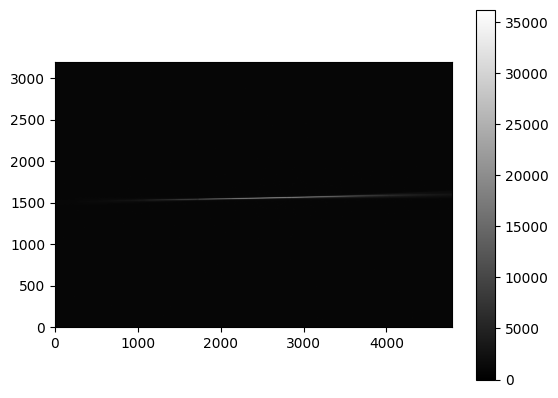

In [71]:
# Select desired image index
img_data = get_img_data(max_exptime_images[img_index]) 
plot_img(img_data)

Fit Line Created: y = 0.0195x + 1508.0635
R-squared Value: 0.9999280939375359


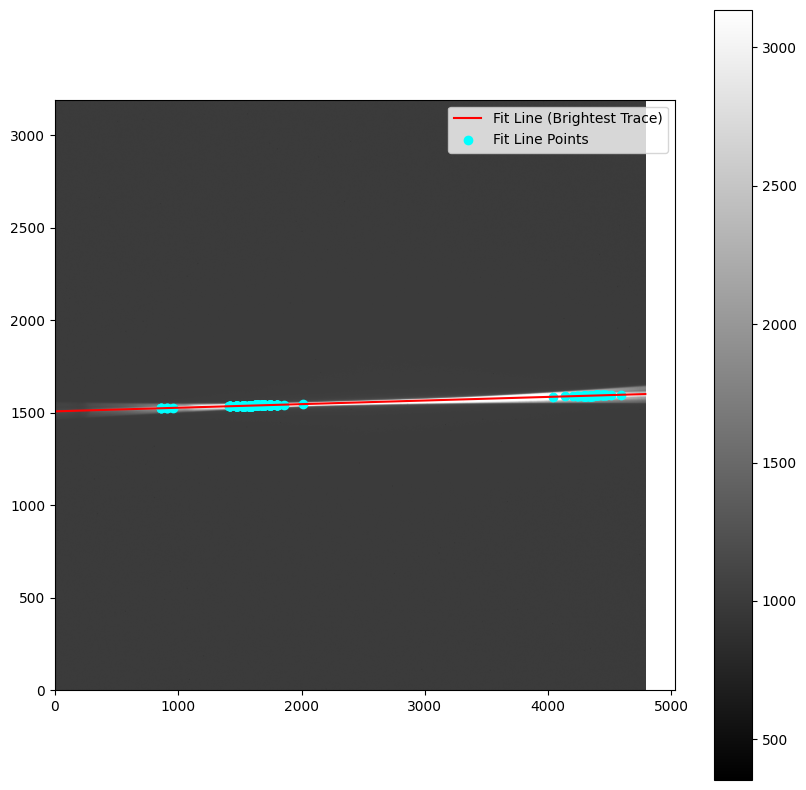

In [72]:
fitline = fit_line(img_data)

In [73]:
# Calculate the angle of the line
angle = np.arctan(fitline[0])
print(np.degrees(angle))
print(f"Taking into account that each chunk is 50 pixels wide, the angle is {np.degrees(angle):.3f} degrees")

1.1193229045096293
Taking into account that each chunk is 50 pixels wide, the angle is 1.119 degrees


Spectral Trace  1  is located at y =  1554.0


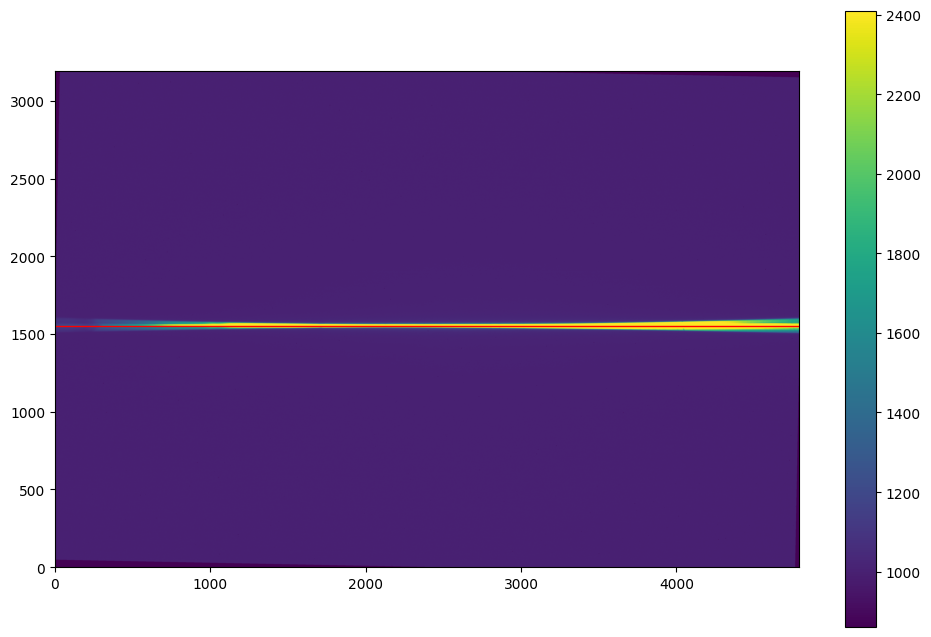

In [74]:
# Rotate the image by the angle
from scipy.ndimage import rotate
rotated_img = rotate(img_data, np.degrees(angle), reshape=False)
traces = find_traces(rotated_img, num_traces = 1)

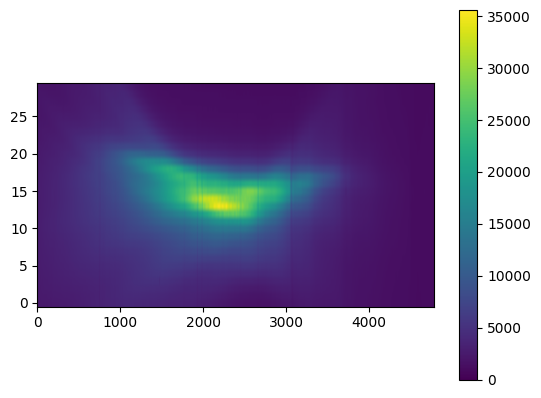

In [75]:
# Get the strip from the rotated image
rotated_strip = extract_strip(np.fliplr(rotated_img), 30, traces[0])
plt.imshow(rotated_strip, cmap='viridis', origin='lower')
# Aspect ratio of 10
plt.gca().set_aspect(90)
plt.colorbar()
plt.show()

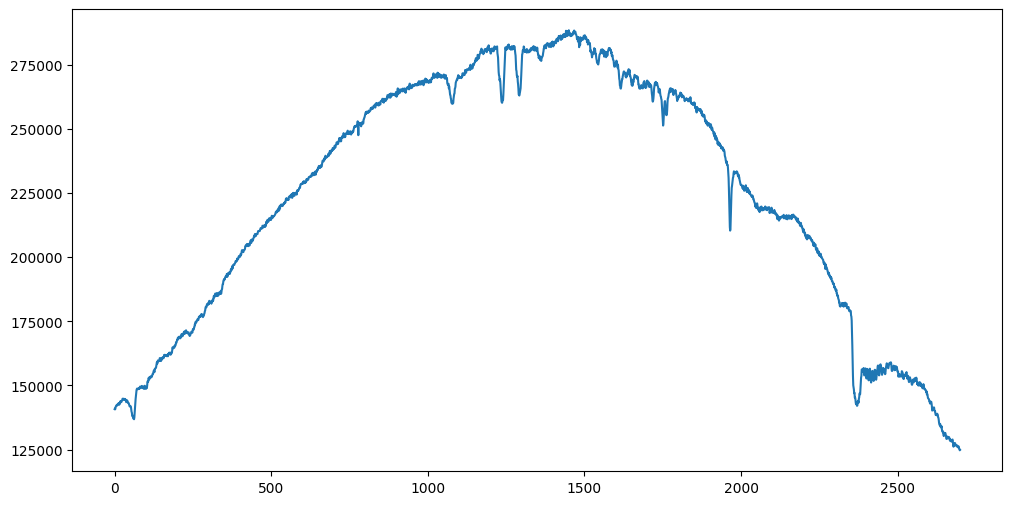

In [76]:
# Sum columns of the rotated strip
col_sum = np.sum(rotated_strip, axis=0)
plt.figure(figsize=(12, 6))
plt.plot(col_sum[700:3400])
plt.show()

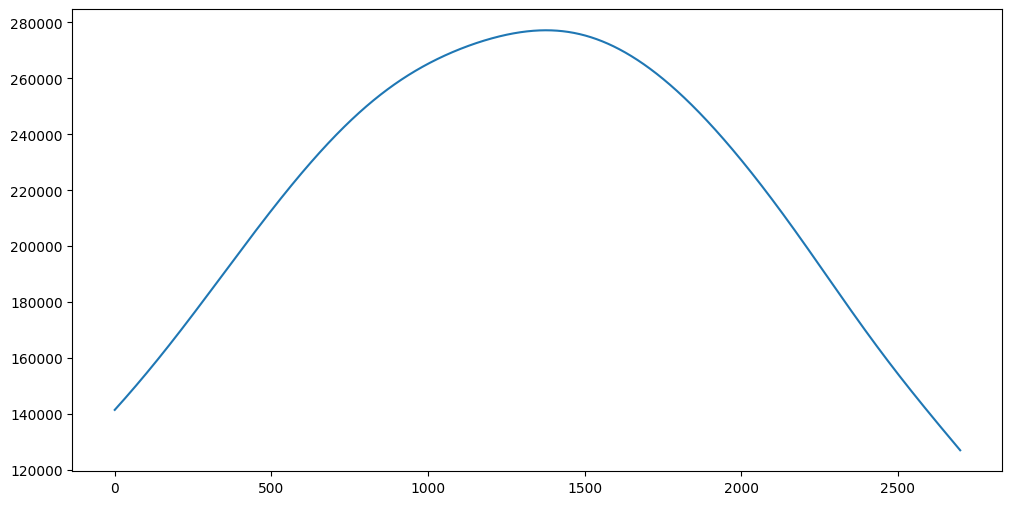

In [77]:
# Smooth the column sum
from scipy.ndimage import gaussian_filter1d
smoothed_col_sum = gaussian_filter1d(col_sum, 200)
plt.figure(figsize=(12, 6))
plt.plot(smoothed_col_sum[700:3400])
plt.show()

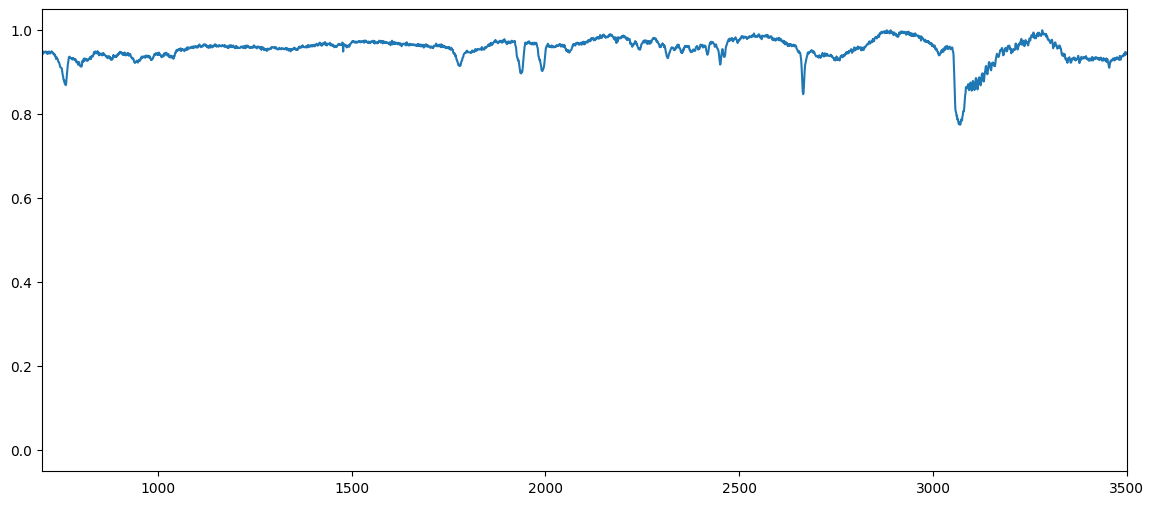

In [78]:
# Divide the smoothed column sum by the maximum value
approx_gain = smoothed_col_sum / np.max(smoothed_col_sum)
norm_spectrum = col_sum / approx_gain
norm_spectrum /= np.max(norm_spectrum)
plt.figure(figsize = (14,6))
plt.plot(norm_spectrum)
plt.xlim(700,3500)
plt.show()

# Use NIST Database Wavelengths for Various Elements to Identify Spectral Features

## Run preliminary wavelength calibration

In [79]:
# We need this function to fit the telluric feature to use as an anchor point

from lmfit.models import VoigtModel, ExponentialModel, SplineModel, LinearModel, GaussianModel

def multi_gauss_with_lin(x, y, x_guess, amp1, amp2):

    amp1 = amp1
    gauss1 = GaussianModel(prefix='g1_')
    pars = gauss1.make_params(center=x_guess, sigma=5)
    pars['g1_amplitude'].set(value=amp1, vary=True, expr='', max=0)
    #pars['v1_gamma'].set(value=2, vary=True, expr='', min=0)

    amp2 = amp2
    gauss2 = GaussianModel(prefix='g2_')
    pars.update(gauss2.make_params(amplitude=-0.5, sigma=5))
    pars['g2_center'].set(value=x_guess+20, vary=True, expr='')
    pars['g2_amplitude'].set(value=amp2, vary=True, expr='', max=0)
    #pars['v2_gamma'].set(value=2, vary=True, expr='', min=0)

    #knot_xvals = np.array([x_guess-50, x_guess-45, x_guess-40, x_guess-35, x_guess-30, x_guess-25, x_guess+25, x_guess+30, x_guess+35, x_guess+40, x_guess+45, x_guess+50])

    bkg = LinearModel(prefix='bkg_')
    pars.update(bkg.guess(y, x))

    mod = gauss1 + gauss2 + bkg

    init = mod.eval(pars, x=x)
    out = mod.fit(y, pars, x=x)

    print(out.fit_report(correl_mode='False'))

    # print just the center of the voigt profiles
    wave_fit = min(out.params['g1_center'].value, out.params['g2_center'].value)

    fig, axes = plt.subplots(1, 2, figsize=(12.8, 4.8))
    axes[0].plot(x, y, alpha = 0.5)
    axes[0].plot(x, init, '--', label='initial fit')
    axes[0].plot(x, out.best_fit, '-', label='best fit')
    axes[0].legend()

    comps = out.eval_components(x=x)
    axes[1].plot(x, y, alpha = 0.5)
    axes[1].plot(x, (comps['g1_']+np.mean(comps['bkg_'])), '--', label='Gauss component 1')
    axes[1].plot(x, (comps['g2_']+np.mean(comps['bkg_'])), '--', label='Gauss component 2')
    axes[1].plot(x, comps['bkg_'], '--', label='Background component')
    axes[1].legend()

    plt.show()

    return wave_fit

In [80]:
# This uses the multi_gauss_with_lin function and finds the telluric line pixel location

def find_telluric(norm_spectrum, prominence = None, recursion = 0):

    if recursion > 40:
        print('Unable to find telluric line')
        return

    # row_data = data[trace_y]
    # smoothed_col_sum = gaussian_filter1d(row_data, 200)
    # approx_gain = smoothed_col_sum / np.max(smoothed_col_sum)
    # norm_spectrum = row_data / approx_gain
    # norm_spectrum /= np.median(norm_spectrum)

    low = 2800
    # low = 2550
    high = 3120

    flipped_spectrum = norm_spectrum*(-1)
    median = np.median(flipped_spectrum)
    std = np.std(flipped_spectrum)

    if prominence is None:
        prominence = 2*std

    peaks, properties = find_peaks(flipped_spectrum,height = median,prominence = prominence)
    peaks_list = []
    for entry in peaks:
        peaks_list.append(entry)

    i=0
    while i < len(peaks_list):
        if peaks_list[i] < low or peaks_list[i] > high:
            del peaks_list[i]
        else:
            i+=1
            continue

    if len(peaks_list) == 0:
        return find_telluric(norm_spectrum, prominence = prominence/2, recursion = recursion + 1)

    if len(peaks_list) > 1:
        return find_telluric(norm_spectrum, prominence = 1.25*prominence, recursion = recursion + 1)

    x = np.linspace(0,len(norm_spectrum)-1,len(norm_spectrum))
    y = norm_spectrum

    x_guess_red = int(np.round(x[peaks_list][0]))
    mask = (x > x_guess_red - 200) & (x < x_guess_red + 200)
    x_red = x[mask]
    y_red = y[mask]
    px_fit_red = int(np.round(multi_gauss_with_lin(x_red, y_red, x_guess_red, -0.2, -0.2)))
    print('')
    print(f"Initial Guess: {x_guess_red}")
    print('')
    print(f"Red Band (Fit): {px_fit_red}")

    if np.abs(px_fit_red - x_guess_red) > 50:
      print('')
      print("Poor Fit, using initial guess value")
      px_fit_red = x_guess_red

    print('')
    print(f"Telluric Line found at x = {x[px_fit_red]}")

    plt.figure(figsize=(18, 6))
    plt.plot(norm_spectrum)
    plt.axvline(x = px_fit_red ,color = 'r',linestyle = '--', linewidth = 0.75, alpha = 0.8, label = 'Telluric Line')
    plt.title('Continuum Normalized Ha Grism Spectrum')
    plt.xlabel('Pixels Location')
    plt.ylabel('Normalized Relative Flux')
    plt.ylim(np.min(norm_spectrum)-2*std, np.max(norm_spectrum)+2*std)
    plt.legend(fontsize = 18)
    plt.show()

    return px_fit_red

[[Model]]
    ((Model(gaussian, prefix='g1_') + Model(gaussian, prefix='g2_')) + Model(linear, prefix='bkg_'))
[[Fit Statistics]]
    # fitting method   = leastsq
    # function evals   = 273
    # data points      = 399
    # variables        = 8
    chi-square         = 0.05450185
    reduced chi-square = 1.3939e-04
    Akaike info crit   = -3534.49436
    Bayesian info crit = -3502.58267
    R-squared          = 0.95528288
[[Variables]]
    g1_amplitude:  -12.6122386 +/- 0.36788865 (2.92%) (init = -0.2)
    g1_center:      3103.90759 +/- 1.16088938 (0.04%) (init = 3070)
    g1_sigma:       47.2127772 +/- 1.09534448 (2.32%) (init = 5)
    g1_fwhm:        111.177592 +/- 2.57933910 (2.32%) == '2.3548200*g1_sigma'
    g1_height:     -0.10657190 +/- 0.00210288 (1.97%) == '0.3989423*g1_amplitude/max(1e-15, g1_sigma)'
    g2_amplitude:  -3.01333120 +/- 0.12937732 (4.29%) (init = -0.2)
    g2_center:      3068.82794 +/- 0.28101790 (0.01%) (init = 3090)
    g2_sigma:       8.75626809 +/- 0.3

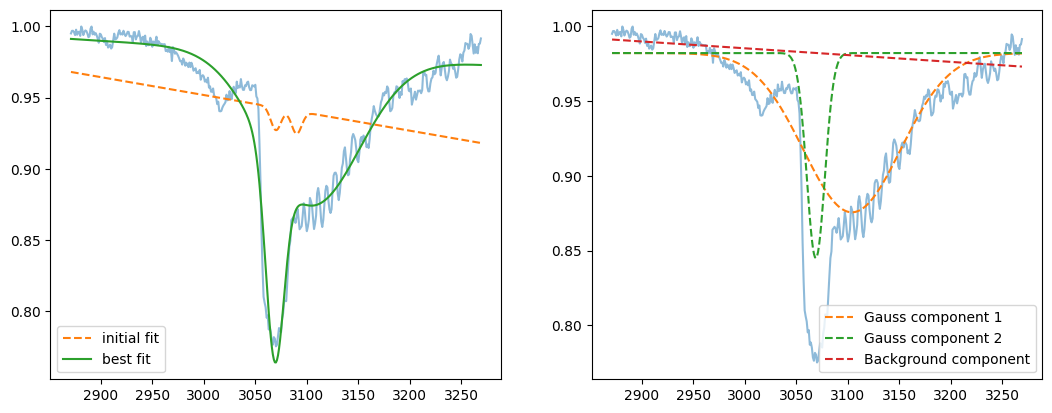


Initial Guess: 3070

Red Band (Fit): 3069

Telluric Line found at x = 3069.0


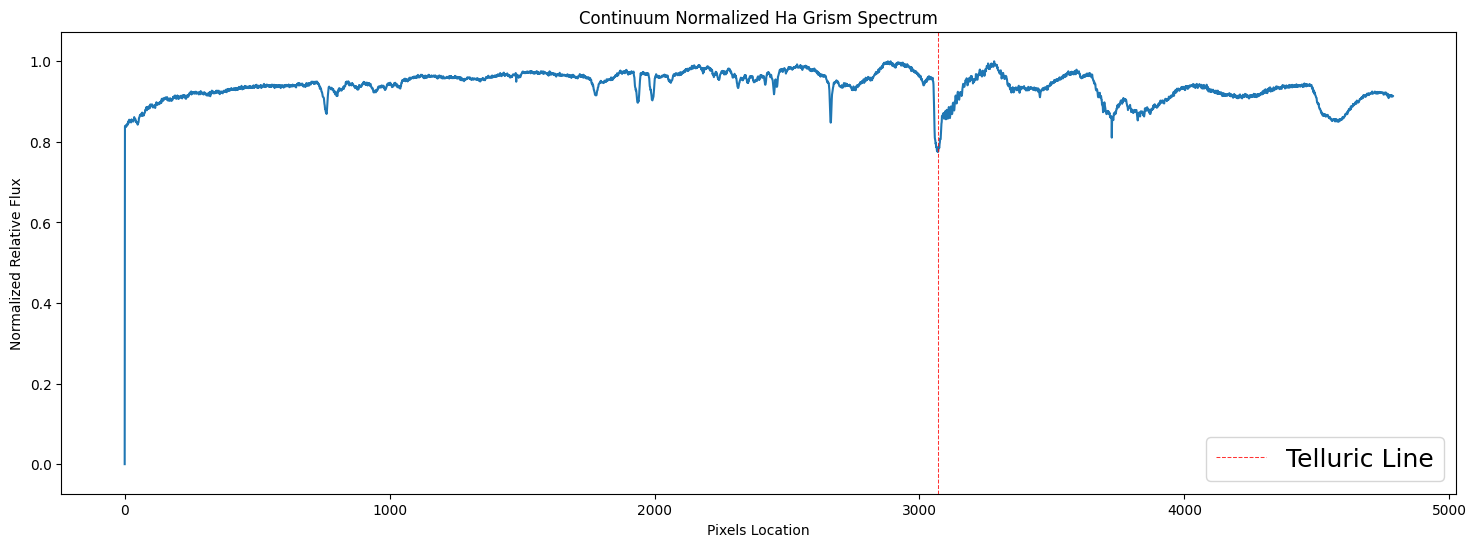

In [81]:
# Find and fit the telluric line pixel location

telluric_x = find_telluric(norm_spectrum)

In [82]:
# This wavelength calibration is based on Rigel

def wavelength_calibrate(spectra):
    spectrum = spectra
    pixel = np.arange(len(spectrum))
    wavelength = 5.80675488e+03 + 3.57909865e-01 * pixel + 2.74912632e-05 * (pixel)**2
    calibrated_spectra = wavelength
    spectrum_out = spectrum
    plt.figure(figsize=(14, 6))
    plt.plot(wavelength[:len(spectrum)-10], spectrum[:len(spectrum)-10])

    plt.axvline(x = 6873.1, label='Red Telluric Line (6873.1 Angstroms)', color='red', linestyle='--')
    plt.axvline(x = 6280.4, label='Blue Telluric Line (6280.4 Angstroms)', color='blue', linestyle='--')
    plt.axvline(x = 6562.8, color = 'pink', linestyle = '--', label = 'H Alpha (Rest, 6562.8 Angstroms)')

    plt.xlim(6200,7000)
    plt.ylim(np.min(spectrum) - np.std(spectrum), np.max(spectrum) + np.std(spectrum))
    plt.xlabel('Wavelength (Angstroms)')
    plt.ylabel('Intensity')
    plt.title('Calibrated Spectrum')
    plt.legend(loc = 'upper right')
    plt.show()
    return calibrated_spectra, spectrum_out

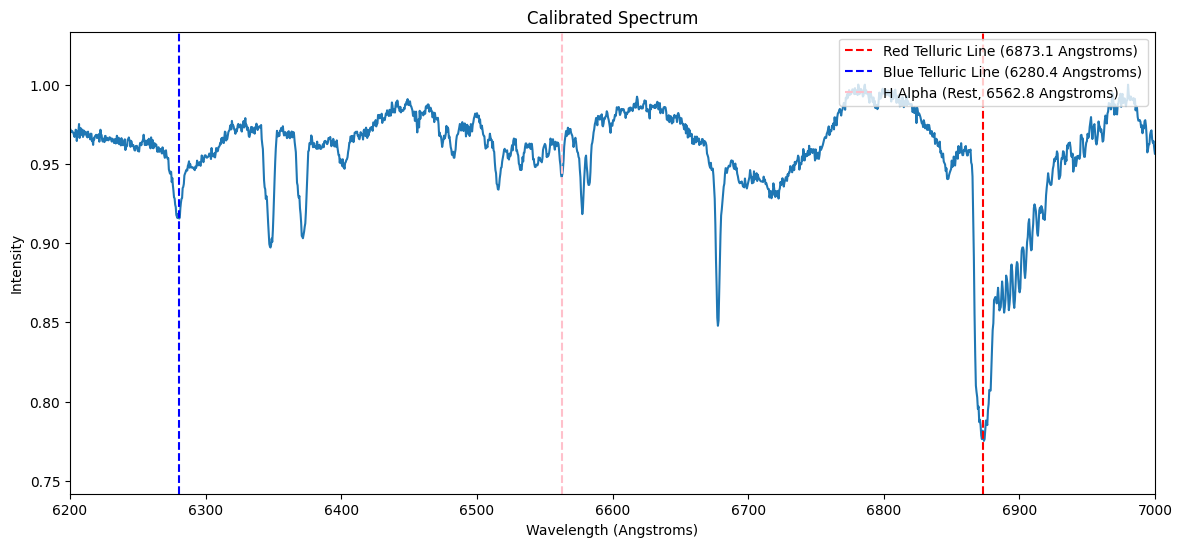

In [83]:
# Create an initial calibrated spectrum using 2500 pixels left of the telluric line as a starting point

calibrated_spectrum, spectrum_out = wavelength_calibrate(norm_spectrum[telluric_x - 2500:])

## Get spectral line info from nist_lines.csv

You will have to put the nist_lines.csv file into a directory of your choice 
then specify the location with nistpath

In [84]:
# Import and read in nist_lines.csv

nistpath = os.path.expanduser('~/gdrive/My Drive/PHYS491-user/Grism_Workbench/')

df = pd.read_csv(nistpath+'nist_lines.csv')
# print(df[['Element', 'Wavelength', 'Name']])
# sort the df by wavelength:
df = df.sort_values(by=['Wavelength'])
print(df[['Element', 'Wavelength', 'Name']])
# print # of transitions loaded:
print(f"Number of transitions loaded: {len(df)}")

   Element  Wavelength               Name
0      C I  5800.59993   C I (5800.59993)
19   Fe II  5807.66610  Fe II (5807.6661)
45    S II  5819.23800    S II (5819.238)
36    He I  5875.61397  He I (5875.61397)
37    He I  5875.61484  He I (5875.61484)
38    He I  5875.62510  He I (5875.62510)
39    He I  5875.64036  He I (5875.64036)
20   Fe II  5885.01440  Fe II (5885.0144)
41    Na I  5889.95094  Na I (5889.95094)
42    Na I  5895.92424  Na I (5895.92424)
21   Fe II  5902.82310  Fe II (5902.8231)
22   Fe II  5914.54700  Fe II (5914.5470)
23   Fe II  5961.70550  Fe II (5961.7055)
1      C I  5969.33151   C I (5969.33151)
2      C I  6001.12300     C I (6001.123)
3      C I  6006.01200     C I (6006.012)
4      C I  6013.16600     C I (6013.166)
5      C I  6013.25180    C I (6013.2518)
6      C I  6016.44870    C I (6016.4487)
43     S I  6052.70400     S I (6052.704)
46    S II  6286.34600    S II (6286.346)
47    S II  6286.95100    S II (6286.951)
48    S II  6305.47900    S II (63

In [85]:
# Define the wavelengths and names to replace (He has a bunch of stuff close together)
he_lines = ['He I (5875.61397)', 'He I (5875.61484)', 'He I (5875.6251)', 'He I (5875.64036)']
blend_name = 'He I (5875.621)'
blend_wavelength = 5875.621

# Update 'Name' and 'Wavelength' for specified He I lines
df.loc[df['Name'].isin(he_lines), 'Name'] = blend_name
df.loc[df['Name'] == blend_name, 'Wavelength'] = blend_wavelength

# Remove duplicates
df = df.drop_duplicates(subset=['Element', 'Wavelength', 'Name'])

# Print the updated DataFrame
pd.set_option('display.max_rows', None)  # Show all rows
print(df[['Element', 'Wavelength', 'Name']])

# Print the number of transitions loaded
print(f"Number of transitions loaded: {len(df)}")

   Element  Wavelength               Name
0      C I  5800.59993   C I (5800.59993)
19   Fe II  5807.66610  Fe II (5807.6661)
45    S II  5819.23800    S II (5819.238)
36    He I  5875.62100    He I (5875.621)
38    He I  5875.62510  He I (5875.62510)
20   Fe II  5885.01440  Fe II (5885.0144)
41    Na I  5889.95094  Na I (5889.95094)
42    Na I  5895.92424  Na I (5895.92424)
21   Fe II  5902.82310  Fe II (5902.8231)
22   Fe II  5914.54700  Fe II (5914.5470)
23   Fe II  5961.70550  Fe II (5961.7055)
1      C I  5969.33151   C I (5969.33151)
2      C I  6001.12300     C I (6001.123)
3      C I  6006.01200     C I (6006.012)
4      C I  6013.16600     C I (6013.166)
5      C I  6013.25180    C I (6013.2518)
6      C I  6016.44870    C I (6016.4487)
43     S I  6052.70400     S I (6052.704)
46    S II  6286.34600    S II (6286.346)
47    S II  6286.95100    S II (6286.951)
48    S II  6305.47900    S II (6305.479)
49    S II  6312.66600    S II (6312.666)
54   Si II  6347.11000    Si II (6

## Plot Spectral Line Info on Calibrated Spectrum and Locate Features

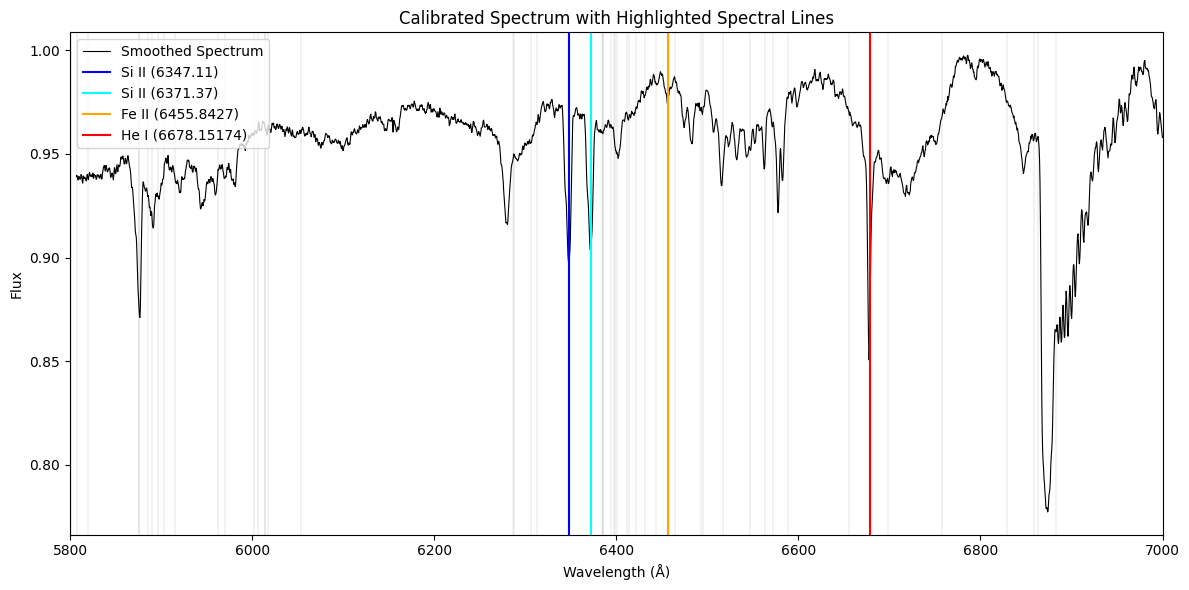

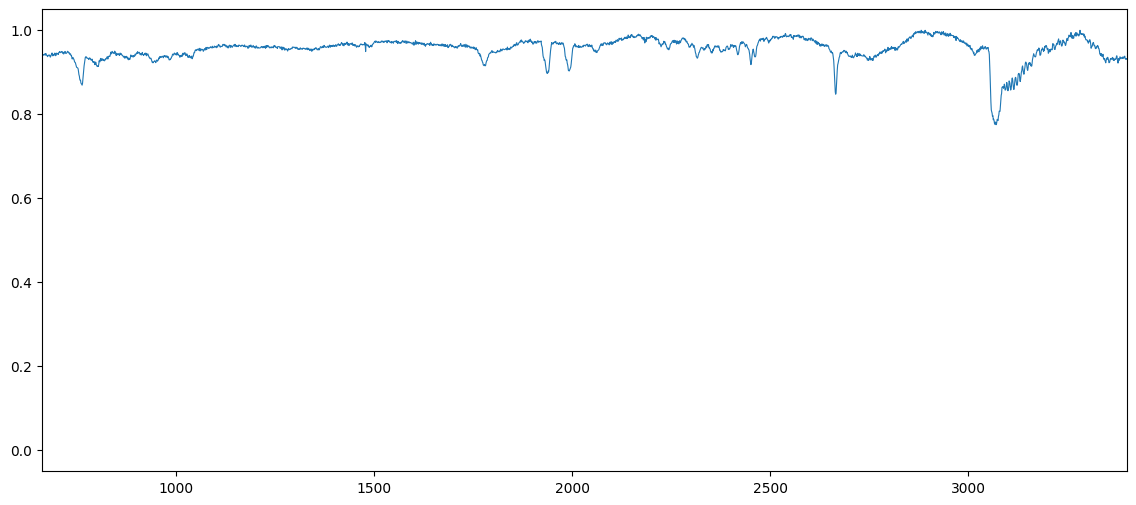

In [86]:
z = (rv*u.km/u.s+radial_vel_correction)/c # For wavelength correction

# Selected line names and their highlight colors
# selected_names = ['He I (5875.621)', 'Si II (6347.11)', 'Si II (6371.37)',
#                   'Fe II (6517.0293)', 'H I (6562.819)', 'He I (6678.15174)']
selected_names = ['Si II (6347.11)', 'Si II (6371.37)',
                  'Fe II (6455.8427)', 'He I (6678.15174)']
selected_colors = ['blue', 'cyan', 'orange', 'red']

# Optional: apply a smoothing if you want, or leave raw
smoothed_spectrum = np.convolve(spectrum_out, np.ones(3)/3, mode='valid')
x_smoothed = calibrated_spectrum[1:-1]

plt.figure(figsize=(12, 6))

# Plot spectrum
# plt.plot(calibrated_spectrum, spectrum_out, color='gray', alpha=0.4, linewidth=0.5)
plt.plot(x_smoothed, smoothed_spectrum, color='black', linewidth=0.8, label='Smoothed Spectrum')

# Plot all lines from df as faint black vertical lines
for _, row in df.iterrows():
    plt.axvline(x=row['Wavelength'] * (1 + z), color='k', linestyle='-', linewidth=0.25, alpha=0.3)

# Highlight selected lines
for i, name in enumerate(selected_names):
    line = df[df['Name'] == name]
    if not line.empty:
        wavelength = line['Wavelength'].values[0] * (1 + z)
        plt.axvline(x=wavelength, color=selected_colors[i], linestyle='-', linewidth=1.5, alpha=1.0, label=name)

# Include any additional lines you think are apparent from the spectral atlas and/or NIST
    # Spectral atlas: https://drive.google.com/drive/folders/18H0q-meNZUt-ChXLOdYd9F55-uaTUqEE
    # NIST: https://physics.nist.gov/PhysRefData/ASD/lines_form.html
# plt.axvline(x = 6137.691*(1 + z), color = 'magenta', linewidth = 1, label = 'Fe I (6137.691)')
# plt.axvline(x = 6230.7219*(1 + z), color = 'red', linewidth = 1, label = 'Fe I (6230.7219)')

plt.xlabel("Wavelength (Å)")
plt.ylabel("Flux")
plt.xlim(5800, 7000)
plt.title("Calibrated Spectrum with Highlighted Spectral Lines")
# plt.legend(bbox_to_anchor=(1.05, 1), loc='lower left')
plt.legend(loc='upper left')
plt.tight_layout()
plt.show()

plt.figure(figsize = (14,6))
plt.plot(norm_spectrum,linewidth = 0.8)
plt.xlim(660,3400)
plt.show()


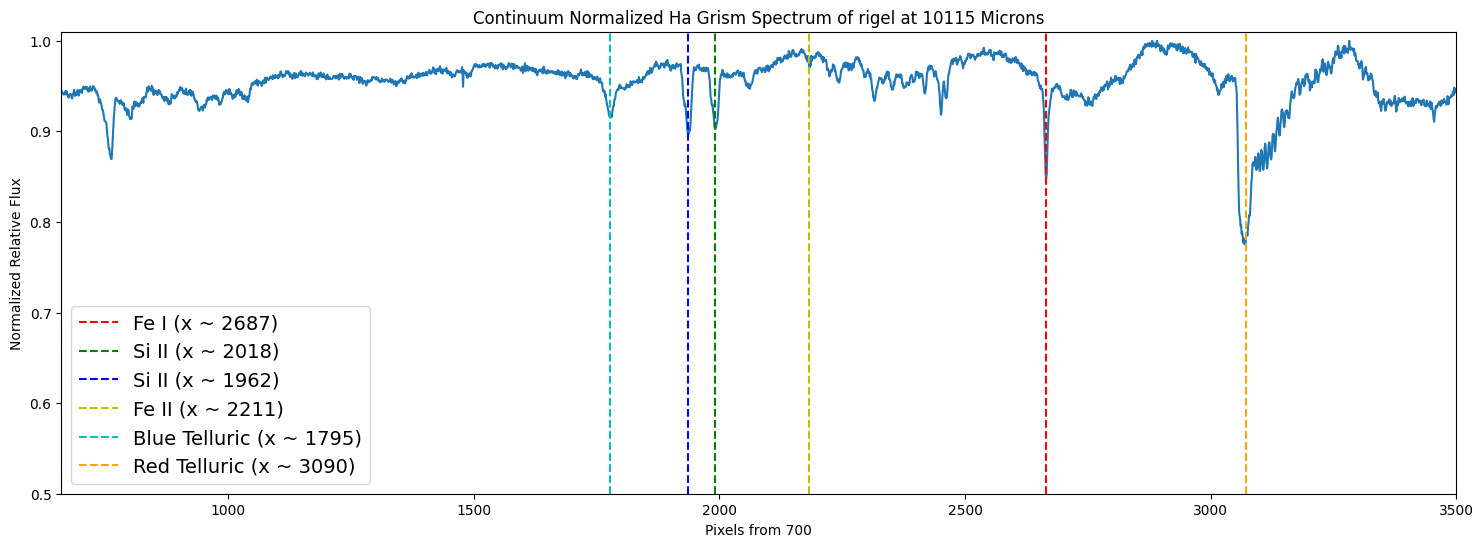

In [87]:
# Use this as a plot to find a rough pixel location of features to use as a guess point then actually fit those features in the code below

shift = 0

plt.figure(figsize=(18, 6))
plt.plot(norm_spectrum)
plt.title(f'Continuum Normalized Ha Grism Spectrum of {target_name} at 10115 Microns')
plt.xlabel('Pixels from 700')
plt.ylabel('Normalized Relative Flux')
# Plot vertical lins at pixel locations of spectral features
plt.axvline(x=2665 + shift, color='r', linestyle='--', label = 'Fe I (x ~ 2687)')
plt.axvline(x=1991 + shift, color='g', linestyle='--', label = 'Si II (x ~ 2018)')
plt.axvline(x=1935 + shift, color='b', linestyle='--', label = 'Si II (x ~ 1962)')
# plt.axvline(x=2419 + shift, color='m', linestyle='--', label = 'H Alpha (x ~ 2445)')
plt.axvline(x=2183 + shift, color='y', linestyle='--', label = 'Fe II (x ~ 2211)')
# plt.axvline(x=2318 + shift, color='k', linestyle='--', label = 'Fe II (x ~ 2345)')

# Make a list to iterate over (match to axvline placements)
pixel_guesses = [1935 + shift, 1991 + shift, 2183 + shift, 2665 + shift] # Do not include relluric lines in this list

plt.axvline(x=1778 + shift, color='c', linestyle='--', label = 'Blue Telluric (x ~ 1795)')
plt.axvline(x=3071 + shift, color='orange', linestyle='--', label = 'Red Telluric (x ~ 3090)')

telluric_guesses = [1778 + shift, 3071 + shift] 

plt.xlim(660,3500)
# Set vertical limits
plt.ylim(0.5, 1.01)
plt.legend(fontsize = 14, loc = 'lower left')
plt.show()

# Fit Lines to Spectral Features

In [88]:
# Here are the functions to fit features

def gaussian(x, a, x0, sigma, offset):
    return a * np.exp(-(x - x0)**2 / (2 * sigma**2)) + offset

def fit_feature(spec_cont, peak_center, width, height, width_guess=None):
    xmin, xmax = peak_center - width, peak_center + width
    peaks, _ = find_peaks(spec_cont[xmin:xmax], height=height, distance=10)
    if width_guess is None:
        width_guess = width
    x = np.arange(xmin, xmax)
    y = spec_cont[xmin:xmax]
    p0 = [height, peak_center, width_guess, 1]
    popt, pcov = curve_fit(gaussian, x, y, p0=p0)

    # Plot
    plt.figure(figsize=(15,5))
    plt.plot(x, y)
    plt.plot(x, gaussian(x, *popt))
    plt.title('Fit of absorption line')
    plt.xlabel('Pixel')
    plt.ylabel('Normalized intensity')
    plt.show()
    return popt



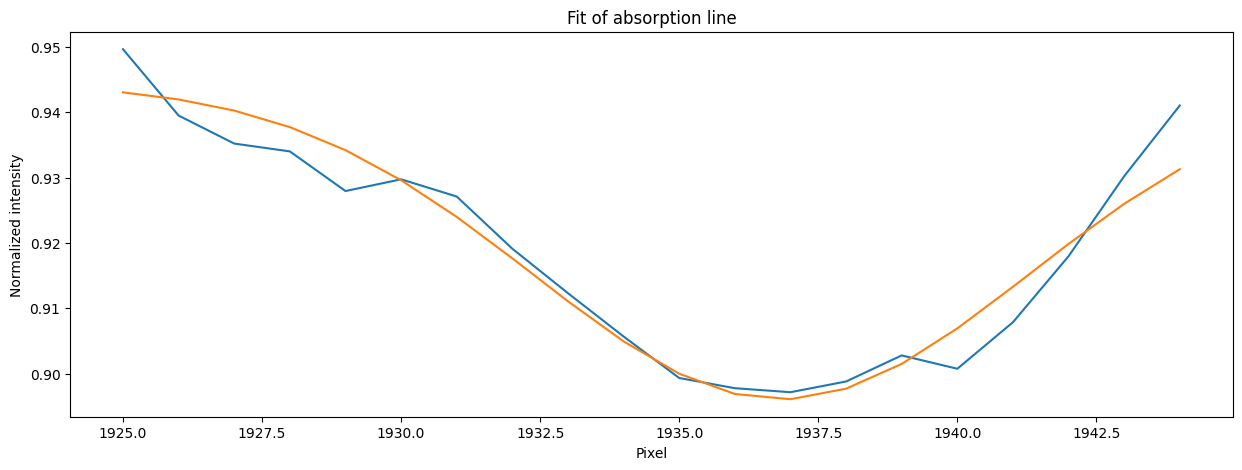

FWHM: 10.46
Peak center: 1936.8302715302482


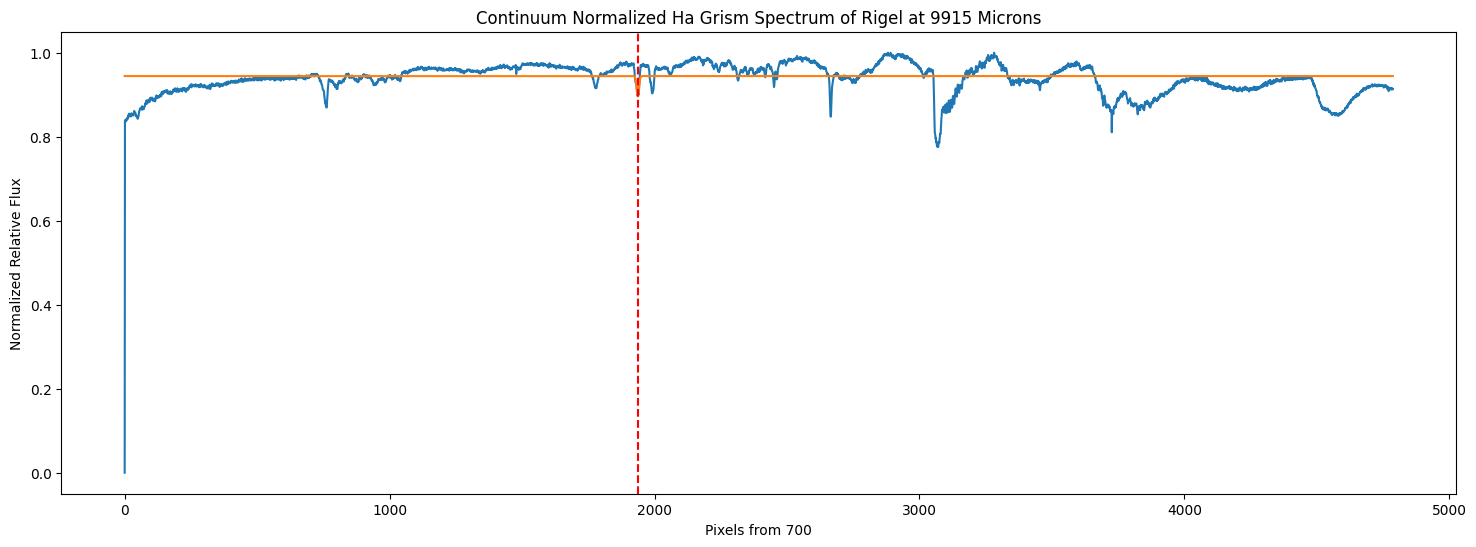

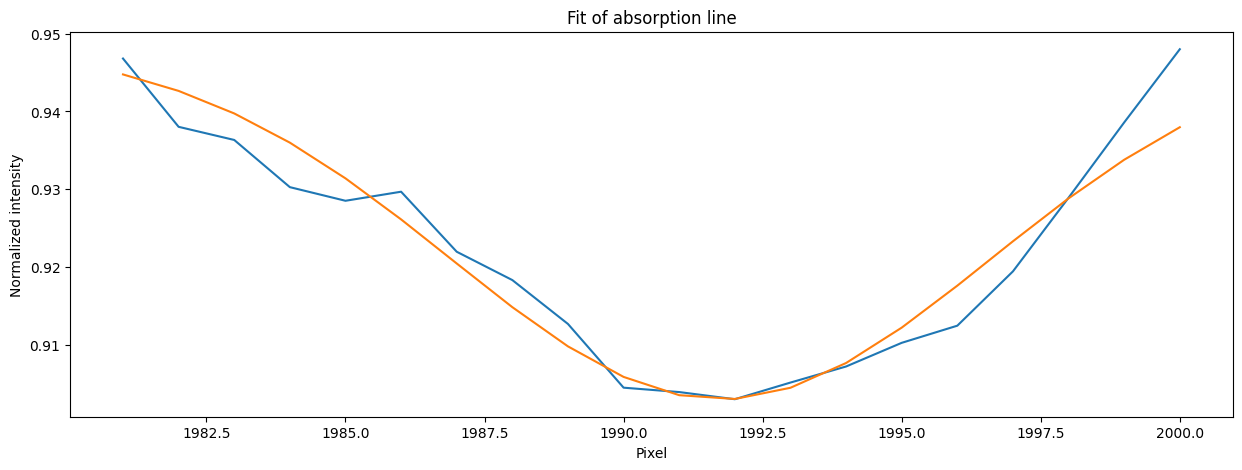

FWHM: 11.38
Peak center: 1991.7503748183174


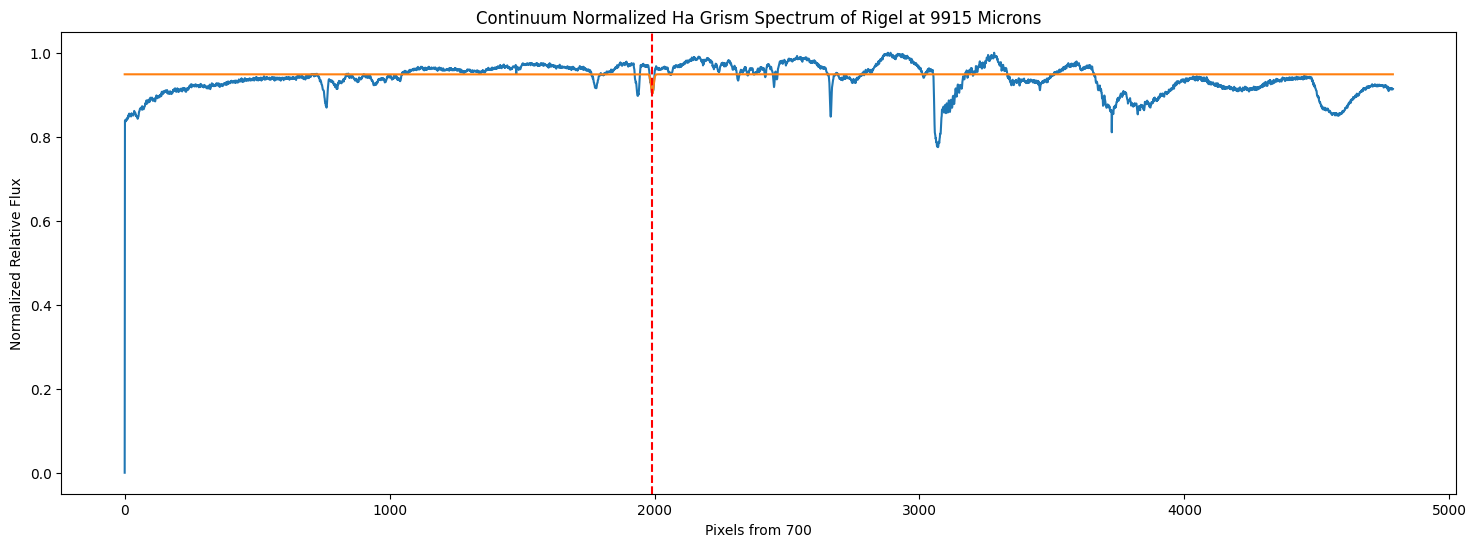

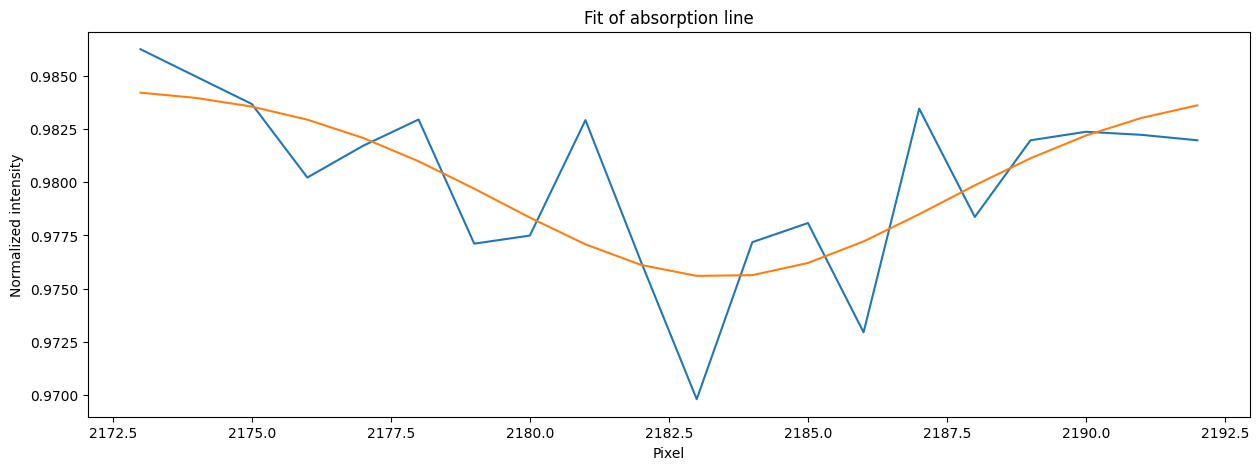

FWHM: 9.37
Peak center: 2183.4411872673927


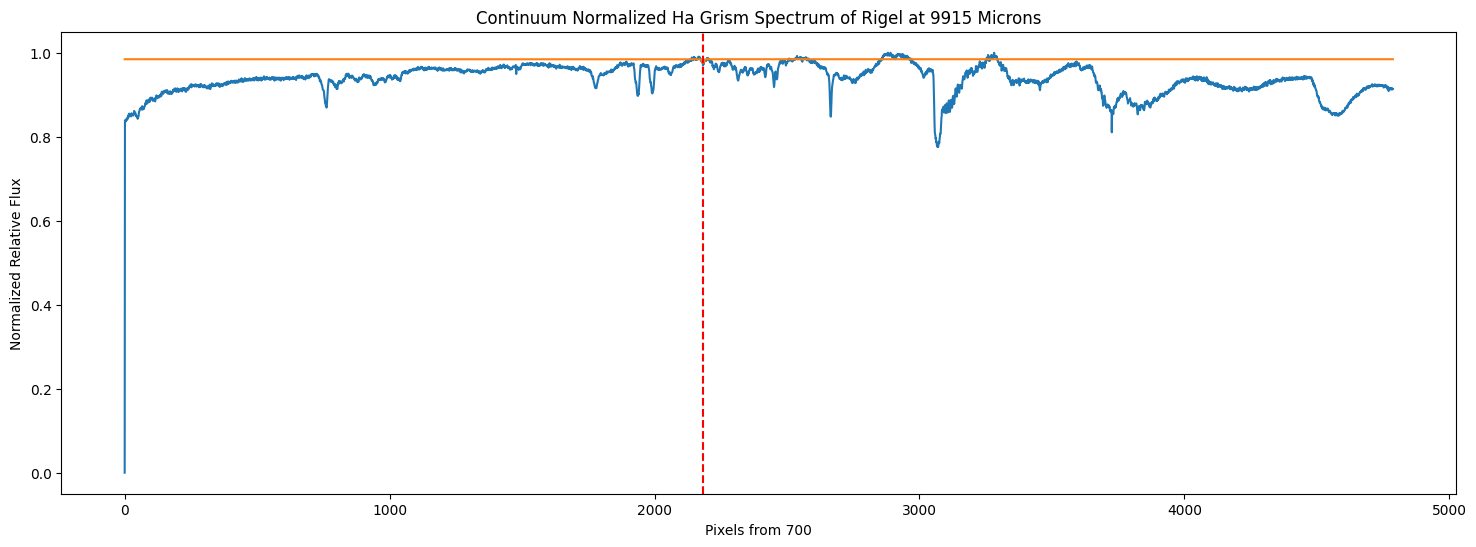

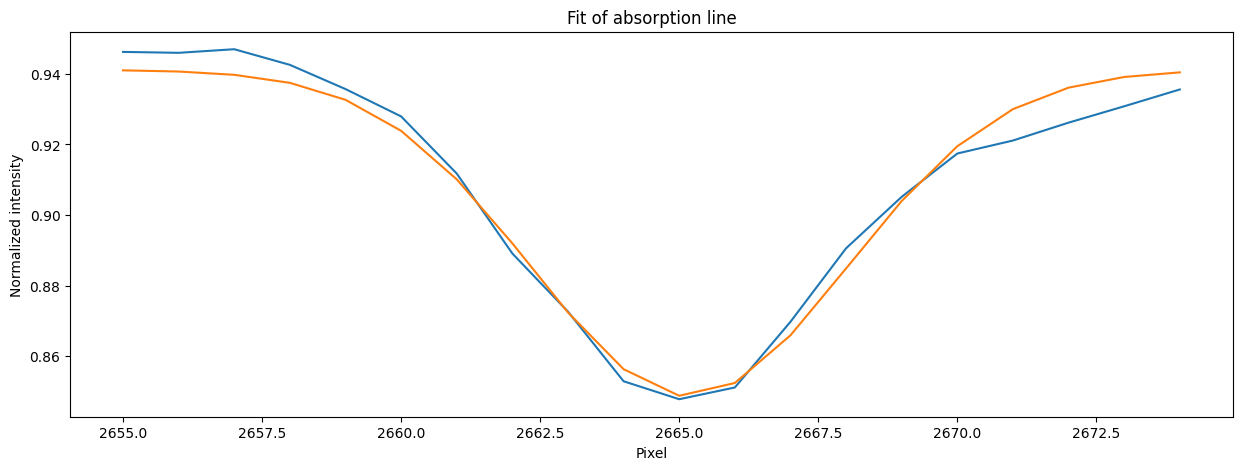

FWHM: 6.66
Peak center: 2665.1803004831363


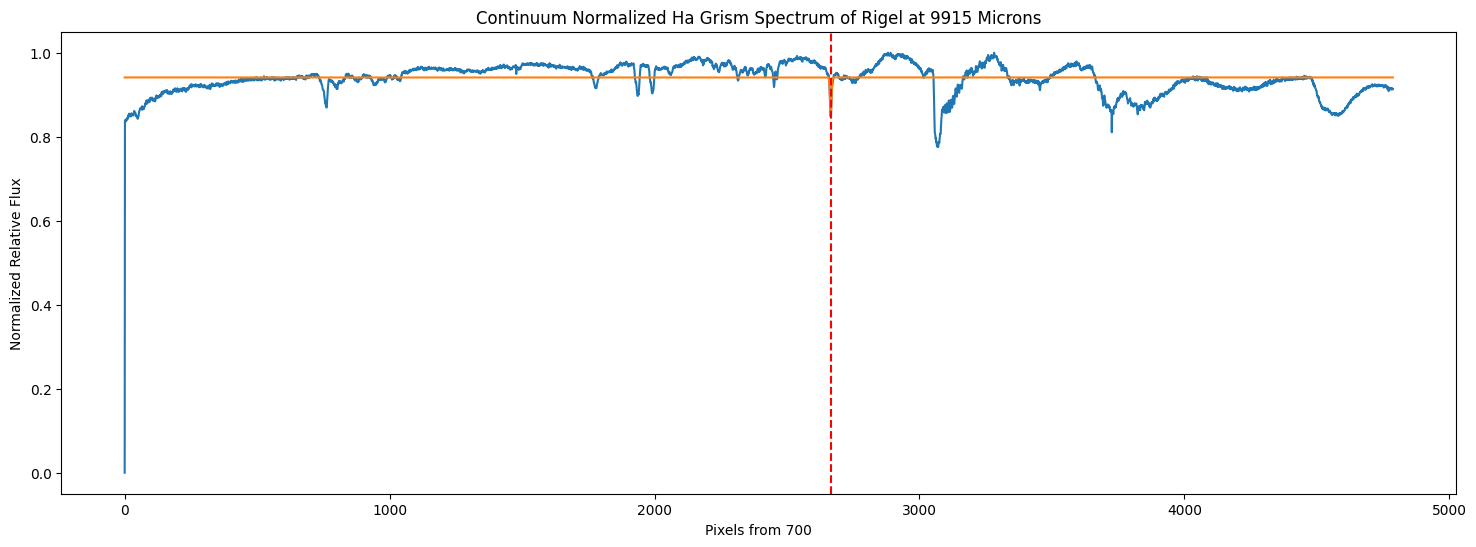

In [89]:
peak_centers = []

for pixel_guess in pixel_guesses:
    popt = fit_feature(norm_spectrum, pixel_guess, 10, -1)
    fwhm = 2 * np.sqrt(2 * np.log(2)) * popt[2]
    print(f"FWHM: {fwhm:.2f}")
    print(f"Peak center: {popt[1]}")

    peak_centers.append(popt[1])

    plt.figure(figsize=(18, 6))
    plt.plot(norm_spectrum)
    plt.plot(gaussian(np.arange(norm_spectrum.shape[0]), *popt))
    plt.title('Continuum Normalized Ha Grism Spectrum of Rigel at 9915 Microns')
    plt.xlabel('Pixels from 700')
    plt.ylabel('Normalized Relative Flux')
    plt.axvline(x=popt[1], color='r', linestyle='--')
    plt.show()

peak_centers.sort()

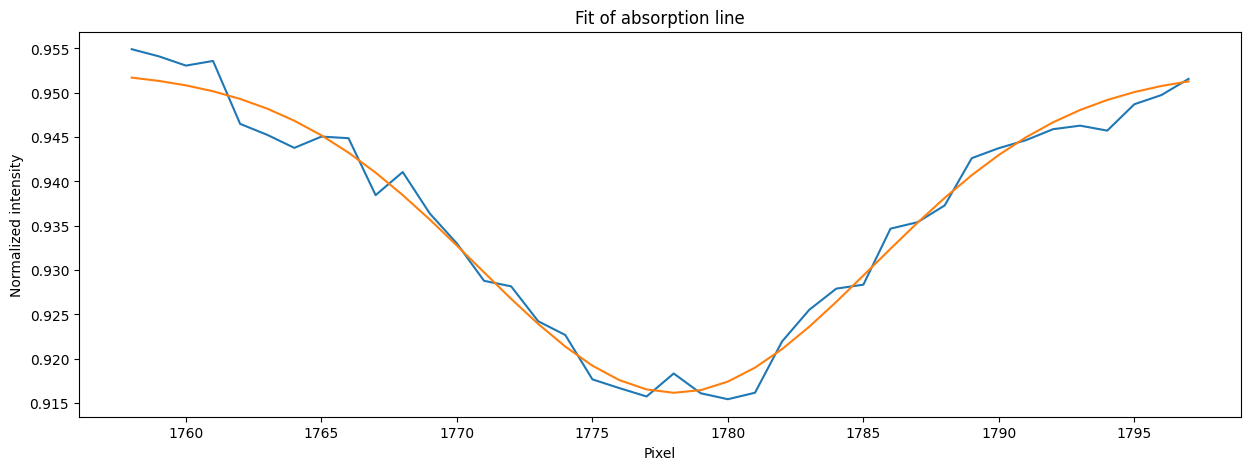

FWHM: 6.66
Peak center: 1778.059655758686


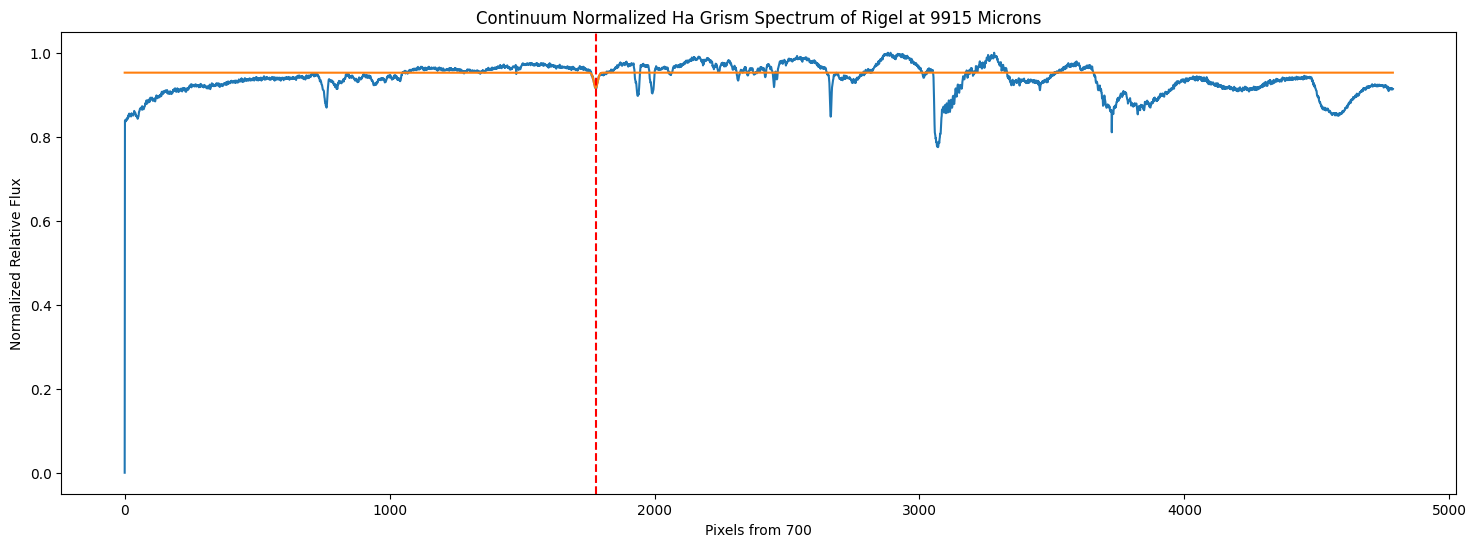

In [90]:
# Fit the blue telluric features

telluric_guesses.sort()

bt_popt = fit_feature(norm_spectrum, telluric_guesses[0], 20, -1)

fwhm = 2 * np.sqrt(2 * np.log(2)) * popt[2]
print(f"FWHM: {fwhm:.2f}")
print(f"Peak center: {bt_popt[1]}")

plt.figure(figsize=(18, 6))
plt.plot(norm_spectrum)
plt.plot(gaussian(np.arange(norm_spectrum.shape[0]), *bt_popt))
plt.title('Continuum Normalized Ha Grism Spectrum of Rigel at 9915 Microns')
plt.xlabel('Pixels from 700')
plt.ylabel('Normalized Relative Flux')
plt.axvline(x=bt_popt[1], color='r', linestyle='--')
plt.show()

In [91]:
# Make a list of the wavelengths in the selected_names list

wavelengths = [float(name.split('(')[-1].rstrip(')')) for name in selected_names]

print(wavelengths)

[6347.11, 6371.37, 6455.8427, 6678.15174]


In [92]:
# Apply wavelength correction due to the Earth's motion and target's recessional velocity

corrected_wavelengths = []

for entry in wavelengths:
    corrected_wavelengths.append(float(np.round(entry*wavelength_correction,3)))

In [93]:
# Append the wavelength list with telluric features

btel_peak_center = bt_popt[1]
btel_wavelength = 6280.4
peak_centers.append(btel_peak_center)
corrected_wavelengths.append(btel_wavelength)

rtel_peak_center = telluric_x
rtel_wavelength = 6873.1
peak_centers.append(rtel_peak_center)
corrected_wavelengths.append(rtel_wavelength)

## Check everything lines up with plots in pixel space

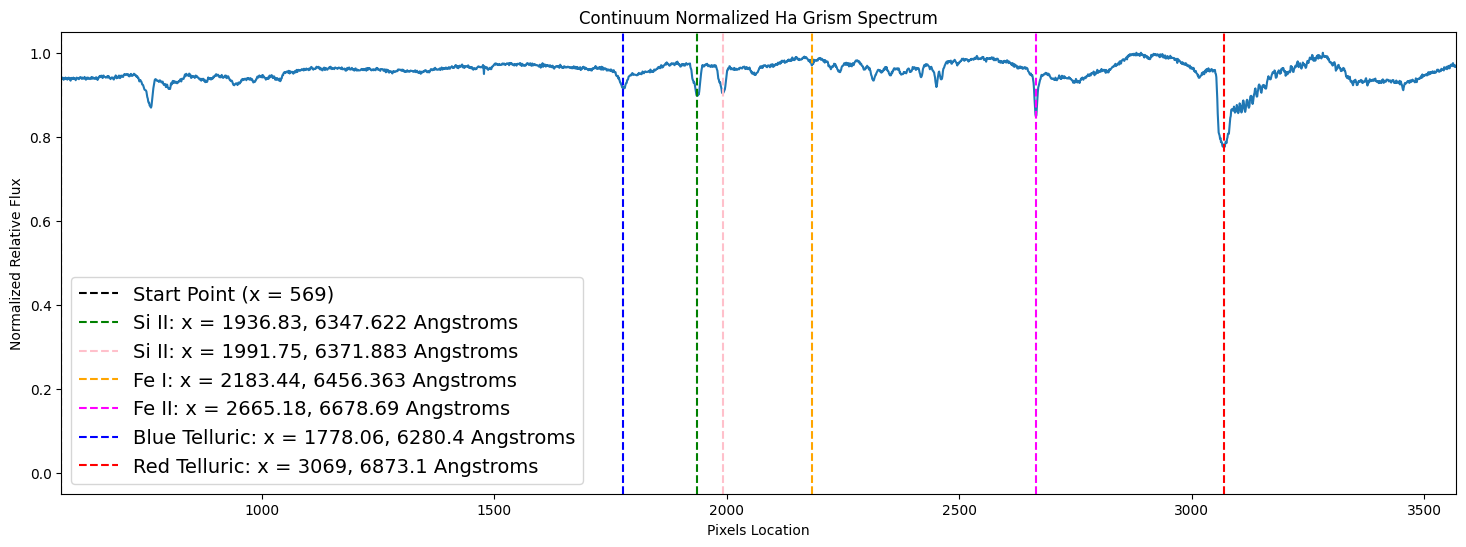

In [99]:
#Plot everything in pixel space to confirm

plt.figure(figsize=(18, 6))
plt.plot(norm_spectrum)
# plt.scatter(telluric_x,norm_spectrum[int(telluric_x)],color = 'r',marker = 'x', label = 'Telluric Line')
plt.axvline(x = telluric_x - 2500, color = 'black', linestyle = '--', label = f'Start Point (x = {telluric_x-2500})')

plt.axvline(x = peak_centers[0], color = 'green', linestyle = '--', label = f'Si II: x = {np.round(peak_centers[0],2)}, {corrected_wavelengths[0]} Angstroms')
plt.axvline(x = peak_centers[1], color = 'pink', linestyle = '--', label = f'Si II: x = {np.round(peak_centers[1],2)}, {corrected_wavelengths[1]} Angstroms')
plt.axvline(x = peak_centers[2], color = 'orange', linestyle = '--', label = f'Fe I: x = {np.round(peak_centers[2],2)}, {corrected_wavelengths[2]} Angstroms')
plt.axvline(x = peak_centers[3], color = 'magenta', linestyle = '--', label = f'Fe II: x = {np.round(peak_centers[3],2)}, {corrected_wavelengths[3]} Angstroms')
# plt.axvline(x = peak_centers[4], color = 'cyan', linestyle = '--', label = f'Ha: x = {np.round(peak_centers[4],2)}, {corrected_wavelengths[4]} Angstroms')
# plt.axvline(x = peak_centers[5], color = 'purple', linestyle = '--', label = f'Na I: x = {np.round(peak_centers[5],2)}, {corrected_wavelengths[5]} Angstroms')

plt.axvline(x = peak_centers[4], color = 'blue', linestyle = '--', label = f'Blue Telluric: x = {np.round(peak_centers[4],2)}, {corrected_wavelengths[4]} Angstroms')
plt.axvline(x = peak_centers[5], color = 'red', linestyle = '--', label = f'Red Telluric: x = {np.round(peak_centers[5],2)}, {corrected_wavelengths[5]} Angstroms')

plt.title('Continuum Normalized Ha Grism Spectrum')
plt.xlabel('Pixels Location')
plt.ylabel('Normalized Relative Flux')
plt.xlim(telluric_x-2500, telluric_x+500)
plt.legend(fontsize = 14, loc = 'lower left')
plt.show()


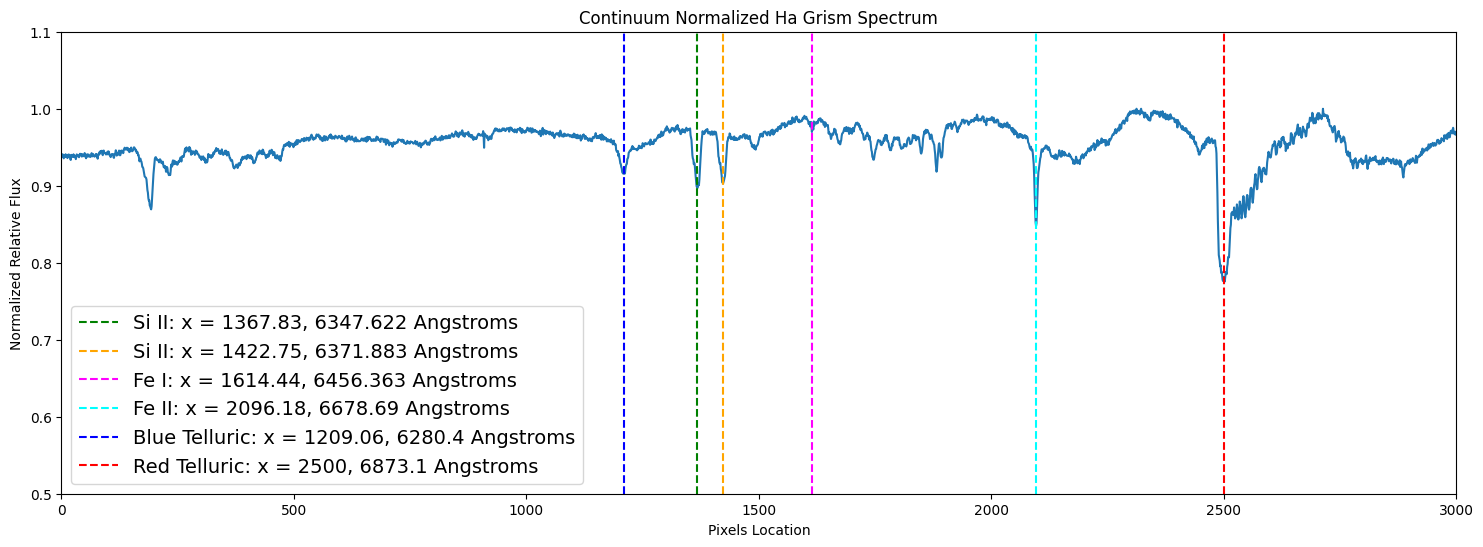

In [100]:
# Set the red telluric point as an anchor point at 2500 pixels for an effective extraction box

start_point = int(telluric_x - 2500)

extract_spectrum = norm_spectrum[start_point:]

extract_peak_centers = []

for entry in peak_centers:
    extract_peak_centers.append(entry-start_point)

#Plot everything in pixel space now for extract

plt.figure(figsize=(18, 6))
plt.plot(norm_spectrum[start_point:])
# plt.scatter(telluric_x-start_point,norm_spectrum[start_point:][int(telluric_x-start_point)],color = 'r',marker = 'x', label = 'Telluric Line')

plt.axvline(x = extract_peak_centers[0], color = 'green', linestyle = '--', label = f'Si II: x = {np.round(extract_peak_centers[0],2)}, {corrected_wavelengths[0]} Angstroms')
plt.axvline(x = extract_peak_centers[1], color = 'orange', linestyle = '--', label = f'Si II: x = {np.round(extract_peak_centers[1],2)}, {corrected_wavelengths[1]} Angstroms')
plt.axvline(x = extract_peak_centers[2], color = 'magenta', linestyle = '--', label = f'Fe I: x = {np.round(extract_peak_centers[2],2)}, {corrected_wavelengths[2]} Angstroms')
plt.axvline(x = extract_peak_centers[3], color = 'cyan', linestyle = '--', label = f'Fe II: x = {np.round(extract_peak_centers[3],2)}, {corrected_wavelengths[3]} Angstroms')
# plt.axvline(x = extract_peak_centers[4], color = 'yellow', linestyle = '--', label = f'Fe II: x = {np.round(extract_peak_centers[4],2)}, {corrected_wavelengths[4]} Angstroms')
# plt.axvline(x = extract_peak_centers[5], color = 'purple', linestyle = '--', label = f'Ha: x = {np.round(extract_peak_centers[5],2)}, {corrected_wavelengths[5]} Angstroms')

plt.axvline(x = extract_peak_centers[4], color = 'blue', linestyle = '--', label = f'Blue Telluric: x = {np.round(extract_peak_centers[4],2)}, {corrected_wavelengths[4]} Angstroms')
plt.axvline(x = extract_peak_centers[5], color = 'red', linestyle = '--', label = f'Red Telluric: x = {np.round(extract_peak_centers[5],2)}, {corrected_wavelengths[5]} Angstroms')

plt.ylim(0.5,1.1)
plt.title('Continuum Normalized Ha Grism Spectrum')
plt.xlabel('Pixels Location')
plt.ylabel('Normalized Relative Flux')
plt.xlim(0,3000)
plt.legend(fontsize = 14, loc = 'lower left')
plt.show()


In [101]:
extract_peak_centers.sort()
wavelengths.sort()
corrected_wavelengths.sort()

print(f"Pixel Peak Centers: {extract_peak_centers}")
print(f'Wavelengths: {wavelengths}')
print(f'Corrected + Telluric Wavelengths: {corrected_wavelengths}')

Pixel Peak Centers: [np.float64(1209.059655758686), np.float64(1367.8302715302482), np.float64(1422.7503748183174), np.float64(1614.4411872673927), np.float64(2096.1803004831363), 2500]
Wavelengths: [6347.11, 6371.37, 6455.8427, 6678.15174]
Corrected + Telluric Wavelengths: [6280.4, 6347.622, 6371.883, 6456.363, 6678.69, 6873.1]


# Derive Wavelength Calibration


=== Fit Report ===
[[Fit Statistics]]
    # fitting method   = leastsq
    # function evals   = 9
    # data points      = 6
    # variables        = 3
    chi-square         = 0.92718371
    reduced chi-square = 0.30906124
    Akaike info crit   = -5.20417814
    Bayesian info crit = -5.82889973
[[Variables]]
    a:  2.6762e-05 +/- 1.5384e-06 (5.75%) (init = 1e-06)
    b:  0.36042533 +/- 0.00574565 (1.59%) (init = 0)
    c:  5805.00888 +/- 5.04693978 (0.09%) (init = 6414.123)
[[Correlations]] (unreported correlations are < 0.100)
    C(a, b) = -0.9962
    C(b, c) = -0.9956
    C(a, c) = +0.9846

R^2 = 0.999996

Pixel location of H-alpha = 1848.720
New solution λ at Hα pixel  = 6562.8000 Å
Old solution λ at Hα pixel  = 6562.8169 Å
Difference (new - old)       = -0.0169 Å
Uncertainty at Hα pixel     = ±0.4273 Å


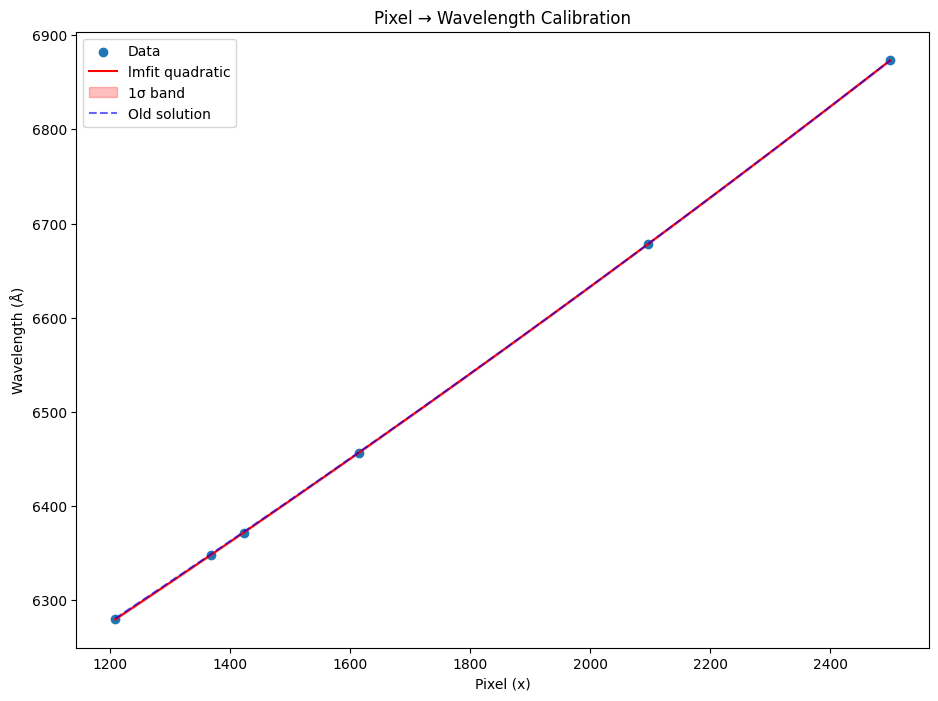

In [102]:
from lmfit import Minimizer, Parameters, report_fit

# ---------------------------------------------------------
# Data
# ---------------------------------------------------------
xdata = np.asarray(extract_peak_centers)
ydata = np.asarray(corrected_wavelengths)

# Pixel grid for visualization
low = int(np.min(xdata))
high = int(np.max(xdata))
xplot = np.linspace(low, high, high-low+1)

# ---------------------------------------------------------
# lmfit model
# ---------------------------------------------------------
def residual(params, x, data):
    a = params['a'].value
    b = params['b'].value
    c = params['c'].value
    return a*x**2 + b*x + c - data

params = Parameters()
params.add('a', value=1e-6)
params.add('b', value=0.0)
params.add('c', value=np.median(ydata))

mini = Minimizer(residual, params, fcn_args=(xdata, ydata))
result = mini.minimize()

print("\n=== Fit Report ===")
report_fit(result)

a = result.params['a'].value
b = result.params['b'].value
c = result.params['c'].value

# Best-fit curve
yfit = a*xplot**2 + b*xplot + c

# ---------------------------------------------------------
# R^2 calculation
# ---------------------------------------------------------
resid = ydata - (a*xdata**2 + b*xdata + c)
ss_res = np.sum(resid**2)
ss_tot = np.sum((ydata - np.mean(ydata))**2)
r2 = 1 - ss_res/ss_tot
print(f"\nR^2 = {r2:.6f}")

# ---------------------------------------------------------
# Parameter covariance → uncertainty propagation
# ---------------------------------------------------------
cov = result.covar
if cov is None:
    print("WARNING: covariance matrix unavailable — uncertainties cannot be computed.")
else:
    # Build Jacobian for every pixel in xplot
    J = np.vstack([xplot**2, xplot, np.ones_like(xplot)])  # (3,N)
    var_y = np.einsum('ij,jk,ik->i', J.T, cov, J.T)
    sigma_y = np.sqrt(np.maximum(var_y,0))

# ---------------------------------------------------------
# OLD wavelength solution
# ---------------------------------------------------------
def old_solution(x):
    return 5809.515939 + 0.3564304348*x + 0.00002760895652*x**2

# ---------------------------------------------------------
# FIND PIXEL COORDINATE OF H-alpha
# new solution solves a*x^2 + b*x + (c - 6562.8) = 0
# ---------------------------------------------------------
Hα = 6562.8
coeffs = [a, b, c - Hα]
roots = np.roots(coeffs)

# pick the real root inside pixel range
x_Ha = roots[np.isreal(roots)].real
x_Ha = x_Ha[(x_Ha>=low) & (x_Ha<=high)]
if len(x_Ha) == 0:
    print("Could not determine x-pixel for H-alpha inside fit range.")
    x_Ha = None
else:
    x_Ha = float(x_Ha[0])
    print(f"\nPixel location of H-alpha = {x_Ha:.3f}")

    # wavelength from both solutions
    new_λ_Ha = a*x_Ha**2 + b*x_Ha + c
    old_λ_Ha = old_solution(x_Ha)
    diff_Ha = new_λ_Ha - old_λ_Ha

    print(f"New solution λ at Hα pixel  = {new_λ_Ha:.4f} Å")
    print(f"Old solution λ at Hα pixel  = {old_λ_Ha:.4f} Å")
    print(f"Difference (new - old)       = {diff_Ha:.4f} Å")

    # uncertainty at that pixel
    if cov is not None:
        J_Ha = np.array([x_Ha**2, x_Ha, 1.0])
        var_Ha = J_Ha.T @ cov @ J_Ha
        sigma_Ha = np.sqrt(np.maximum(var_Ha, 0))
        print(f"Uncertainty at Hα pixel     = ±{sigma_Ha:.4f} Å")

# ---------------------------------------------------------
# Plotting
# ---------------------------------------------------------
plt.figure(figsize=(11,8))
plt.scatter(xdata, ydata, label='Data')
plt.plot(xplot, yfit, 'r', label='lmfit quadratic')

if cov is not None:
    plt.fill_between(xplot, yfit - sigma_y, yfit + sigma_y,
                     alpha=0.25, color='red', label='1σ band')

plt.plot(xplot, old_solution(xplot), 'b--', alpha=0.6, label='Old solution')
plt.xlabel('Pixel (x)')
plt.ylabel('Wavelength (Å)')
plt.title('Pixel → Wavelength Calibration')
plt.legend()
plt.show()

## (Optional): Check r-squared value

In [51]:
from sklearn.metrics import r2_score

poly_func = np.poly1d(p)  # Create a polynomial function from coefficients

# Generate predicted values
y_pred = poly_func(extract_peak_centers)

# Compute R-squared value
r_squared = r2_score(corrected_wavelengths, y_pred)

# Print results
print(f"Quadratic Coefficients: {p}")
print(f"Quadratic Equation: {poly_func}")
print(f"R^2: {r_squared:.8f}")

# Plot data and quadratic fit
plt.scatter(extract_peak_centers, corrected_wavelengths, label="Data Points", color='blue')
x_fit = np.linspace(min(extract_peak_centers), max(extract_peak_centers), 100)  # Smooth curve
y_fit = poly_func(x_fit)
plt.plot(x_fit, y_fit, label="Quadratic Fit", color='red')
plt.xlabel("Extract Peak Centers")
plt.ylabel("Corrected Wavelengths")
plt.legend()
plt.title("Quadratic Fit to Peak Centers vs. Wavelengths")
plt.show()


ModuleNotFoundError: No module named 'sklearn'

# Test New Wavelength Calibration

In [70]:
# This wavelength calibration is now based on your selected target

def new_wavelength_calibrate(spectra, p):
    spectrum = spectra
    pixel = np.arange(len(spectrum))
    wavelength = p[2] + p[1] * pixel + p[0] * (pixel)**2
    calibrated_spectra = wavelength
    spectrum_out = spectrum
    plt.figure(figsize=(14, 6))
    plt.plot(wavelength[:len(spectrum)-10], spectrum[:len(spectrum)-10])

    plt.axvline(x = 6873.1, label='Red Telluric Line (6873.1 Angstroms)', color='red', linestyle='--')
    plt.axvline(x = 6280.4, label='Blue Telluric Line (6280.4 Angstroms)', color='blue', linestyle='--')
    plt.axvline(x = 6562.8*wavelength_correction, color = 'pink', linestyle = '--', label = f'H Alpha ({np.round(6562.8*wavelength_correction,3)} Angstroms)')

    plt.xlim(6200,7000)
    plt.ylim(np.min(spectrum) - np.std(spectrum), np.max(spectrum) + np.std(spectrum))
    plt.xlabel('Wavelength (Angstroms)')
    plt.ylabel('Intensity')
    plt.title('Calibrated Spectrum')
    plt.legend(loc = 'upper right')
    plt.show()
    return calibrated_spectra, spectrum_out

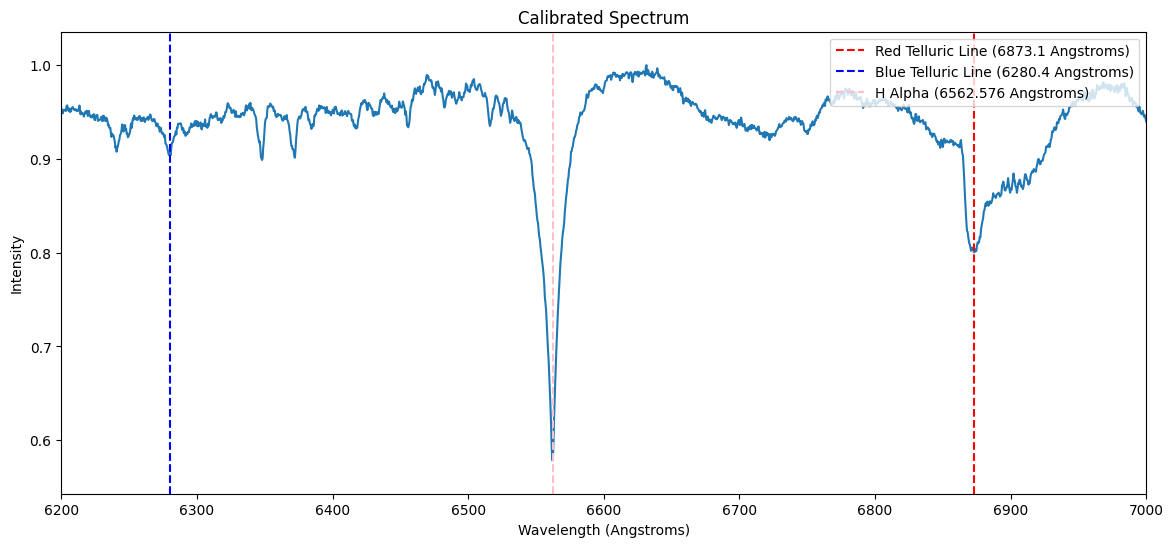

(array([5811.87402128, 5812.22725571, 5812.58054722, ..., 7795.76801337,
        7796.36067344, 7796.95339058], shape=(4198,)),
 array([0.90982497, 0.90639496, 0.9083714 , ..., 0.9073342 , 0.90613914,
        0.90459114], shape=(4198,), dtype=float32))

In [71]:
# See if Ha and the telluric lines match up!

new_wavelength_calibrate(norm_spectrum[telluric_x-2500:],p)

[2.85370244e-05 3.53205894e-01 5.81187402e+03]


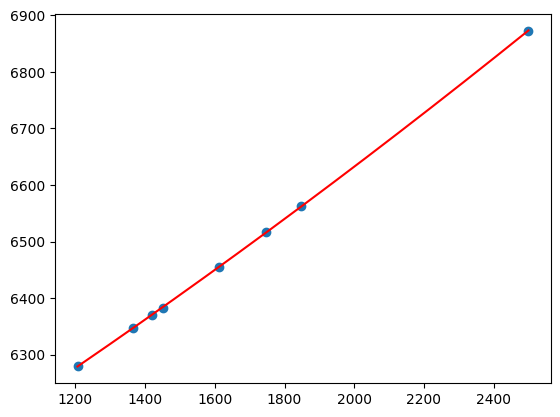

In [72]:
low = int(np.min(extract_peak_centers))
high = int(np.max(extract_peak_centers))
x = np.linspace(low, high, high-low)

fit = np.polyfit(extract_peak_centers, corrected_wavelengths, 2)
fitline = fit[0]*x**2 + fit[1]*x + fit[2]

# fit = np.polyfit(extract_peak_centers, corrected_wavelengths, 1)
# fitline = fit[0]*x + fit[1]

print(fit)

plt.scatter(extract_peak_centers, corrected_wavelengths)
plt.plot(x,fitline, color = 'red')

In [73]:
# Fit 2nd order polynomial to the peak centers
p = np.polyfit(extract_peak_centers, corrected_wavelengths, 2)
print(p)

[2.85370244e-05 3.53205894e-01 5.81187402e+03]


In [74]:
print(' a = '+str(np.round(p[0],9)))
print(' b = '+str(np.round(p[1],4)))
print(' c = '+str(np.round(p[2],4)))
print(f'Red Telluric: x = '+str(telluric_x))

 a = 2.8537e-05
 b = 0.3532
 c = 5811.874
Red Telluric: x = 3090
